# Online Shoppers Purchase Intention Prediction

---

## Project Overview

This project analyzes the **Online Shoppers Purchasing Intention Dataset** to predict whether a visitor will make a purchase (Revenue = True) based on their browsing behavior.

**Team Members:**
- **Mai** - Classification (LightGBM, CatBoost, Ensemble)
- **Đạt** - Classification (Logistic Regression, Decision Tree)
- **My** - Clustering (K-Means, DBSCAN)

**Dataset:** 12,330 sessions with 18 features including page views, duration, bounce rates, and visitor information.

---

# Part 1: Data Preprocessing (Common)

## 1.1 Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore FutureWarning and UserWarning for clean outputs
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
# Create a working copy for data processing
# This preserves the original dataframe for reference
df_clean = df.copy()

## 1.2 Data Overview

Explore the basic structure and properties of the dataset.

In [3]:
# Check dataset dimensions and column names
print(f"Dataset shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
df_clean.columns

Dataset shape: (12330, 18)

Columns (18):


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [4]:
# Check data types for each column
df_clean.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [5]:
# Check for missing values
df_clean.isna().sum().sort_values(ascending=False)

Administrative             0
Administrative_Duration    0
Weekend                    0
VisitorType                0
TrafficType                0
Region                     0
Browser                    0
OperatingSystems           0
Month                      0
SpecialDay                 0
PageValues                 0
ExitRates                  0
BounceRates                0
ProductRelated_Duration    0
ProductRelated             0
Informational_Duration     0
Informational              0
Revenue                    0
dtype: int64

In [6]:
# Check for duplicate rows (exact matches across all columns)
dup_mask = df_clean.duplicated(keep=False)
dup_count = dup_mask.sum()
dup_pct = (dup_count / len(df_clean)).round(4)

# Group duplicates to see the most common duplicate patterns
dup_groups = df_clean[dup_mask].groupby(list(df_clean.columns)).size().sort_values(ascending=False)
print(f"Top 10 duplicate groups:")
print(dup_groups.head(10))
print(f"\nTotal duplicate rows: {dup_count} ({dup_pct:.2%})")

Top 10 duplicate groups:
Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  Browser  Region  TrafficType  VisitorType        Weekend  Revenue
0               0.0                      0              0.0                     1               0.0                      0.2          0.2        0.0         0.0         Mar    2                 2        1       1            Returning_Visitor  False    False      14
                                                                                                                                                                         May    2                 2        1       3            Returning_Visitor  False    False       7
                                                                                                                                                                         Mar    3      

In [7]:
# Remove exact duplicate rows (keep first occurrence)
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)
removed = before - after

print(f"Before: {before:,} rows")
print(f"After:  {after:,} rows")
print(f"Removed: {removed:,} duplicate rows")

Before: 12,330 rows
After:  12,205 rows
Removed: 125 duplicate rows


In [8]:
# Statistical summary of all columns
df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12205.0,NaN,NaN,NaN,2.338878,3.330436,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12205.0,NaN,NaN,NaN,81.646331,177.491845,0.0,0.0,9.0,94.7,3398.75
Informational,12205.0,NaN,NaN,NaN,0.508726,1.275617,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12205.0,NaN,NaN,NaN,34.825454,141.424807,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12205.0,NaN,NaN,NaN,32.045637,44.593649,0.0,8.0,18.0,38.0,705.0
ProductRelated_Duration,12205.0,NaN,NaN,NaN,1206.982457,1919.6014,0.0,193.0,608.942857,1477.154762,63973.52223
BounceRates,12205.0,NaN,NaN,NaN,0.02037,0.045255,0.0,0.0,0.002899,0.016667,0.2
ExitRates,12205.0,NaN,NaN,NaN,0.041466,0.046163,0.0,0.014231,0.025,0.048529,0.2
PageValues,12205.0,NaN,NaN,NaN,5.949574,18.653671,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12205.0,NaN,NaN,NaN,0.061942,0.199666,0.0,0.0,0.0,0.0,1.0


## 1.3 Data Distributions

Analyze the distribution of categorical and numeric features.

In [9]:
# Categorical feature distributions
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns
print("Categorical Feature Value Counts:")
{col: df_clean[col].value_counts(dropna=False) for col in cat_cols}

Categorical Feature Value Counts:


{'Month': Month
 May     3329
 Nov     2982
 Mar     1860
 Dec     1706
 Oct      549
 Sep      448
 Aug      433
 Jul      432
 June     285
 Feb      181
 Name: count, dtype: int64,
 'VisitorType': VisitorType
 Returning_Visitor    10431
 New_Visitor           1693
 Other                   81
 Name: count, dtype: int64,
 'Weekend': Weekend
 False    9346
 True     2859
 Name: count, dtype: int64,
 'Revenue': Revenue
 False    10297
 True      1908
 Name: count, dtype: int64}

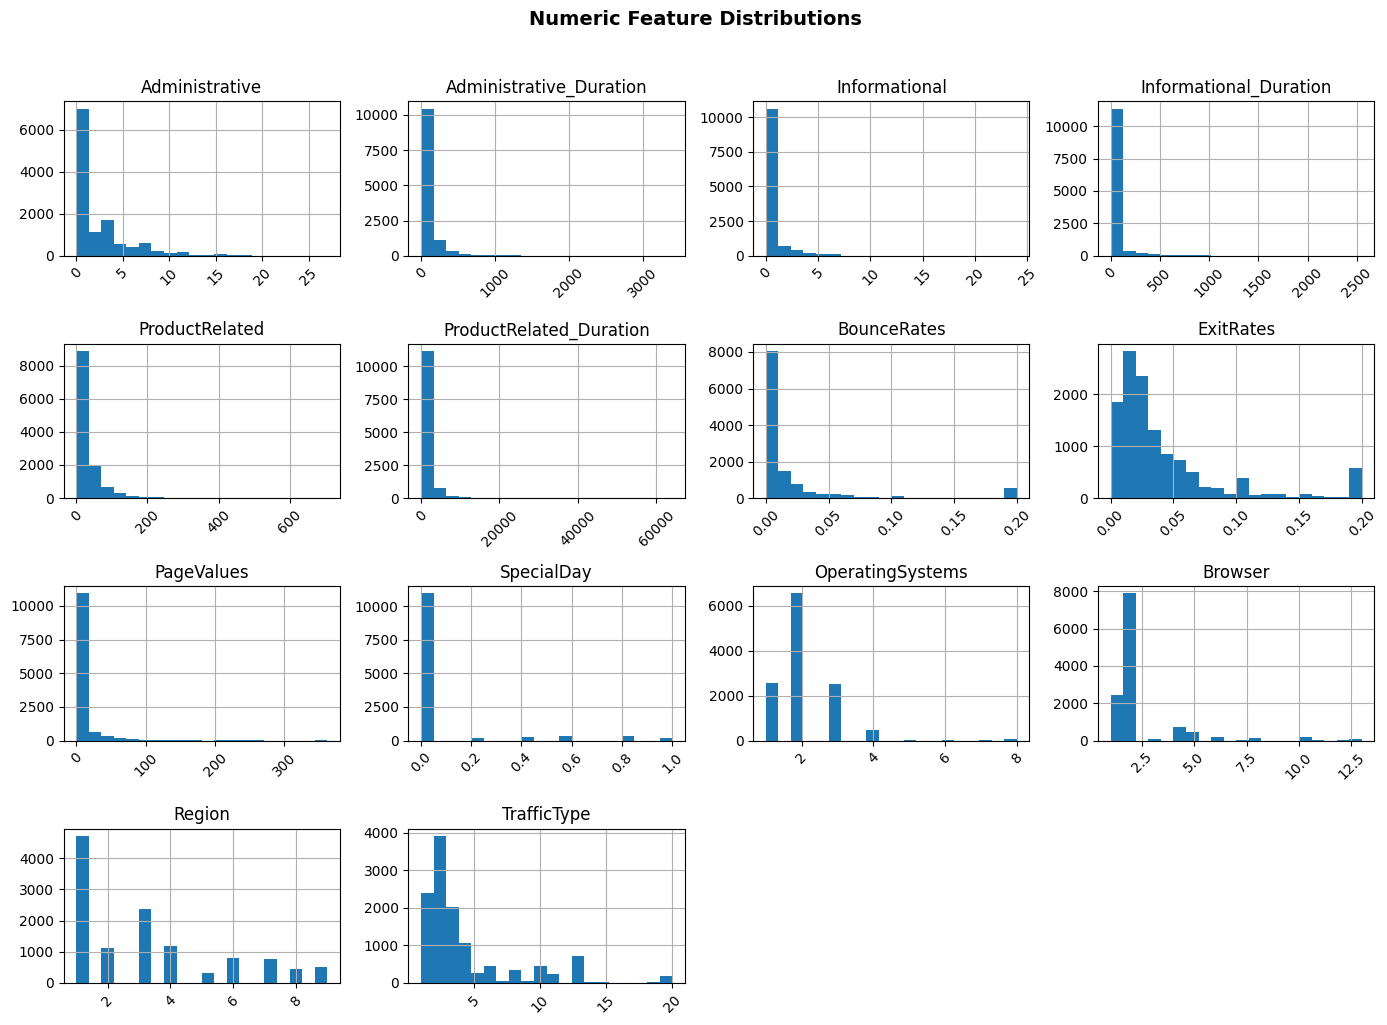

In [10]:
# Numeric feature distributions (histograms)
num_cols = df_clean.select_dtypes(include='number').columns
axes = df_clean[num_cols].hist(figsize=(14, 10), bins=20, layout=(4, 4))
for ax in axes.flatten():
    if ax is not None:
        ax.tick_params(axis='x', labelrotation=45)
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

## 1.4 Outlier Detection and Handling

Identify and handle outliers using IQR method and percentile clipping.

In [11]:
# IQR-based outlier detection for numeric features
outlier_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

# Calculate IQR bounds
q1 = df_clean[outlier_cols].quantile(0.25)
q3 = df_clean[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Identify outliers
outlier_mask = (df_clean[outlier_cols] < lower) | (df_clean[outlier_cols] > upper)
outlier_summary = outlier_mask.sum().sort_values(ascending=False)
outlier_pct = (outlier_summary / len(df_clean)).round(4)

# Create summary table
outlier_table = pd.DataFrame({'outlier_count': outlier_summary, 'outlier_pct': outlier_pct})
print("Outlier Summary (IQR Method):")
outlier_table

Outlier Summary (IQR Method):


,outlier_count,outlier_pct
PageValues,2730,0.2237
Informational,2631,0.2156
Informational_Duration,2405,0.1971
BounceRates,1428,0.1170
ExitRates,1325,0.1086
SpecialDay,1249,0.1023
Administrative_Duration,1149,0.0941
ProductRelated,1007,0.0825
ProductRelated_Duration,951,0.0779
Administrative,404,0.0331


In [12]:
# Outlier handling using clipping (preserves data while limiting extreme values)

# Features bounded between 0 and 1 (rates and proportions)
clip_01_cols = ['BounceRates', 'ExitRates', 'SpecialDay']
for col in clip_01_cols:
    df_clean[col] = df_clean[col].clip(0, 1)

# Other numeric features: clip at 99th percentile to handle extreme outliers
clip_p99_cols = [
    'Administrative', 'Informational', 'ProductRelated',
    'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
    'PageValues'
]
for col in clip_p99_cols:
    p99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=p99)

# Verify clipping results
print("After Outlier Clipping:")
df_clean[clip_01_cols + clip_p99_cols].describe().T[['min', 'max', 'mean', 'std']]

After Outlier Clipping:


,min,max,mean,std
BounceRates,0.0,0.200000,0.020370,0.045255
ExitRates,0.0,0.200000,0.041466,0.046163
SpecialDay,0.0,1.000000,0.061942,0.199666
Administrative,0.0,14.000000,2.309218,3.199232
Informational,0.0,6.000000,0.490455,1.154280
ProductRelated,0.0,221.000000,31.127735,38.331027
Administrative_Duration,0.0,838.704889,77.021957,142.728817
Informational_Duration,0.0,722.379200,30.696256,105.268590
ProductRelated_Duration,0.0,8704.271573,1164.588940,1555.729802
PageValues,0.0,86.108689,5.496011,14.942396


## 1.5 Exploratory Data Analysis (EDA)

Visualize relationships between features and the target variable (Revenue).

In [13]:
# Set visualization style
sns.set_theme(style='whitegrid', context='notebook')

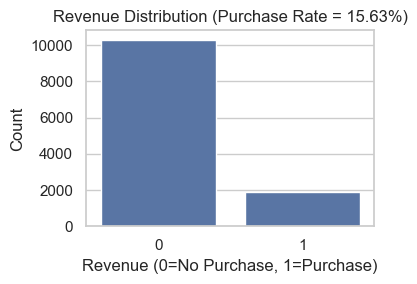

Class Imbalance: 84.4% No Purchase vs 15.6% Purchase


In [14]:
# Target variable distribution (Revenue)
rev_counts = df_clean['Revenue'].value_counts().sort_index()
rev_rate = df_clean['Revenue'].mean()

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=rev_counts.index.astype(int), y=rev_counts.values, ax=ax, color='#4C72B0')
ax.set_title(f'Revenue Distribution (Purchase Rate = {rev_rate:.2%})')
ax.set_xlabel('Revenue (0=No Purchase, 1=Purchase)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Class Imbalance: {(1-rev_rate)*100:.1f}% No Purchase vs {rev_rate*100:.1f}% Purchase")

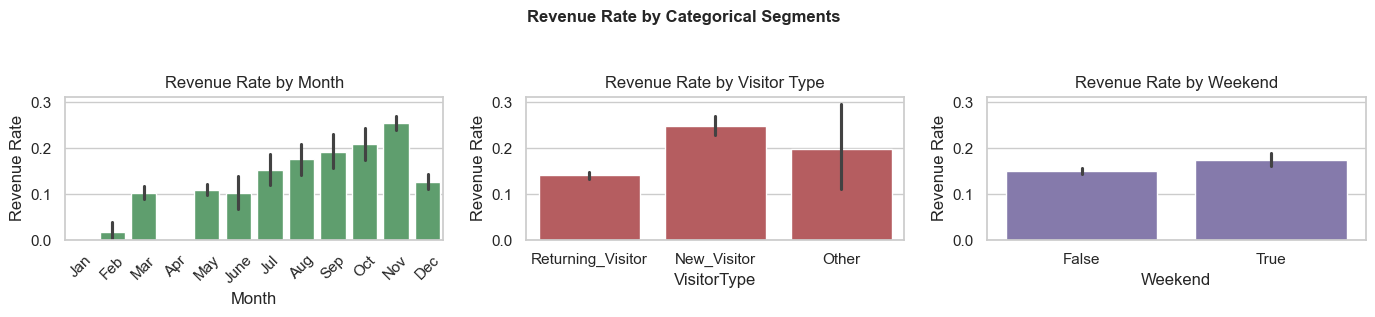

In [15]:
# Revenue rate by categorical segments (Month, VisitorType, Weekend)
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

# Revenue rate by Month
sns.barplot(x='Month', y='Revenue', data=df_clean, order=month_order, ax=axes[0], color='#55A868')
axes[0].set_title('Revenue Rate by Month')
axes[0].tick_params(axis='x', rotation=45)

# Revenue rate by VisitorType
sns.barplot(x='VisitorType', y='Revenue', data=df_clean, ax=axes[1], color='#C44E52')
axes[1].set_title('Revenue Rate by Visitor Type')

# Revenue rate by Weekend
sns.barplot(x='Weekend', y='Revenue', data=df_clean, ax=axes[2], color='#8172B3')
axes[2].set_title('Revenue Rate by Weekend')

for ax in axes:
    ax.set_ylabel('Revenue Rate')
    ax.set_ylim(0, df_clean['Revenue'].mean() * 2 if df_clean['Revenue'].mean() > 0 else 1)

plt.suptitle('Revenue Rate by Categorical Segments', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

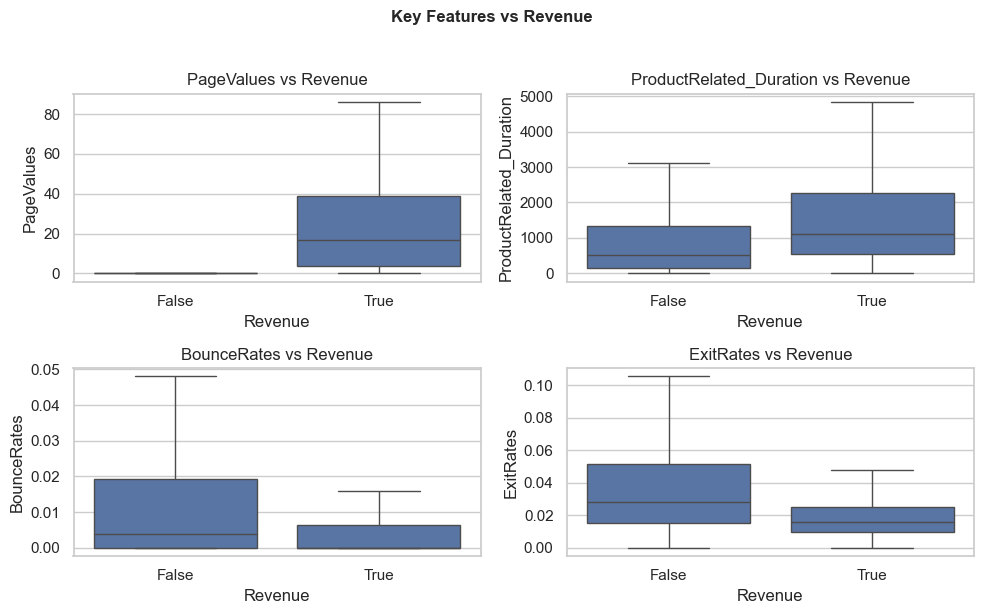

In [17]:
# Key numeric features vs Revenue (boxplots)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.boxplot(x='Revenue', y='PageValues', data=df_clean, ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title('PageValues vs Revenue')

sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df_clean, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('ProductRelated_Duration vs Revenue')

sns.boxplot(x='Revenue', y='BounceRates', data=df_clean, ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('BounceRates vs Revenue')

sns.boxplot(x='Revenue', y='ExitRates', data=df_clean, ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title('ExitRates vs Revenue')

plt.suptitle('Key Features vs Revenue', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

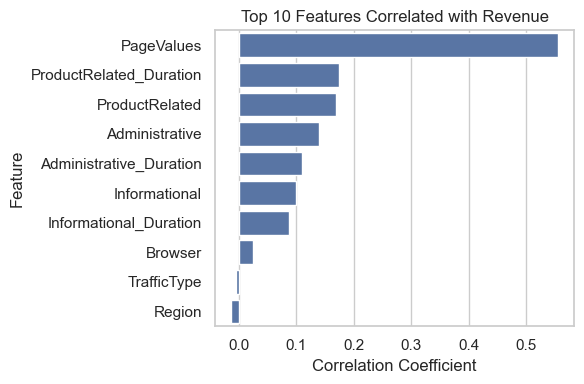

In [18]:
# Top correlations with Revenue
num_df = df_clean.select_dtypes(include='number').copy()
if 'Revenue' not in num_df.columns:
    num_df['Revenue'] = df_clean['Revenue'].astype(int)
    
corr_rev = num_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
top_corr = corr_rev.drop('Revenue').head(10)

plt.figure(figsize=(6, 4))
sns.barplot(x=top_corr.values, y=top_corr.index, color='#4C72B0')
plt.title('Top 10 Features Correlated with Revenue')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 1.6 Correlation Analysis

Examine correlations between all numeric features.

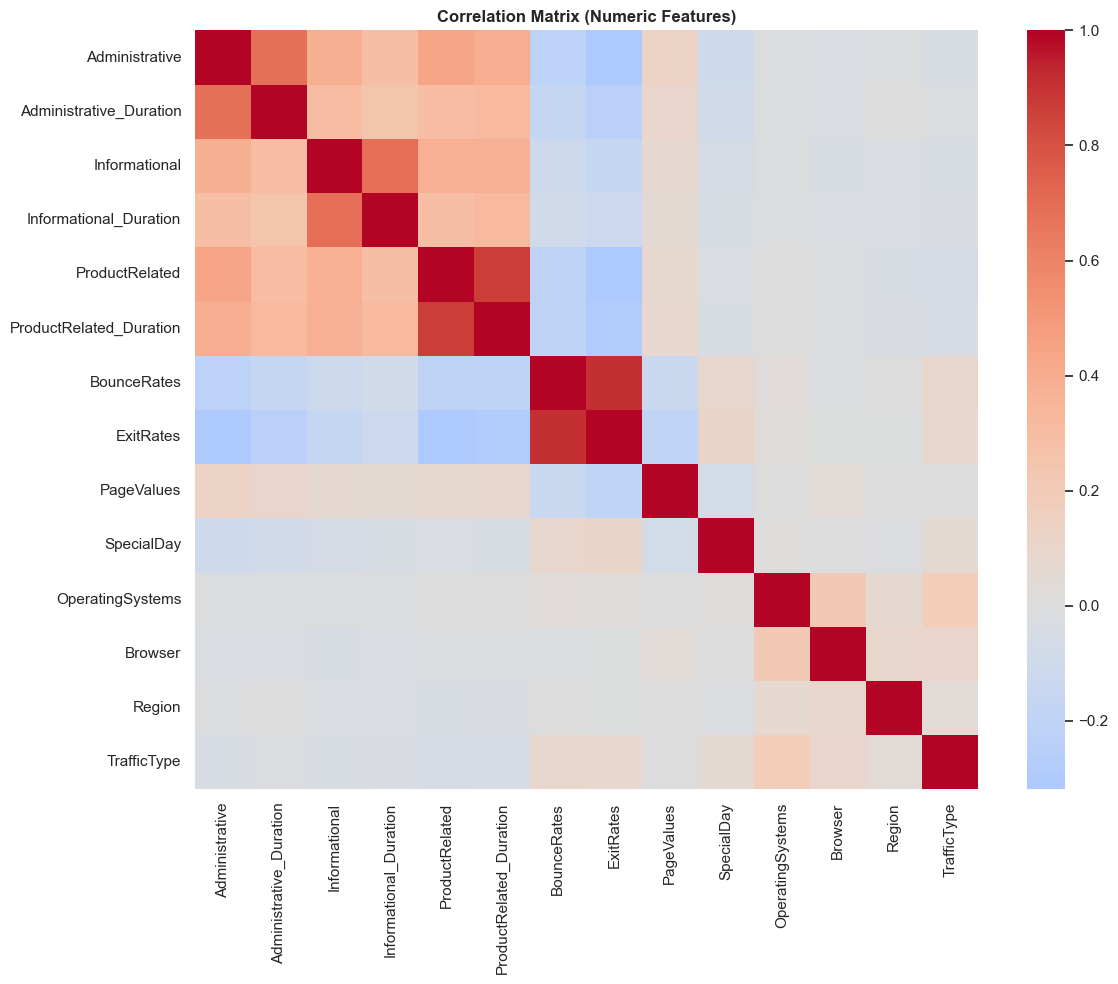

Top 10 Feature Pair Correlations:


BounceRates     ExitRates                  0.902144
ProductRelated  ProductRelated_Duration    0.870249
Informational   Informational_Duration     0.686949
Administrative  Administrative_Duration    0.684665
                ProductRelated             0.440552
                ProductRelated_Duration    0.394693
                Informational              0.381454
Informational   ProductRelated_Duration    0.379471
                ProductRelated             0.378314
Administrative  ExitRates                  0.319570
dtype: float64

In [19]:
# Correlation matrix heatmap
num_df = df_clean.select_dtypes(include='number')
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix (Numeric Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 highest absolute correlations (excluding self-correlations)
corr_abs = corr.abs()
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
top10 = corr_abs.where(mask).stack().sort_values(ascending=False).head(10)
print("Top 10 Feature Pair Correlations:")
top10

## 1.7 Feature Engineering

Create new features to improve model predictive power:

- **Encoding categorical variables:**
  - Month: Cyclical encoding using sin/cos transformation
  - VisitorType: One-hot encoding
  - Weekend/Revenue: Binary encoding (0/1)

- **New derived features:**
  - `Has_PageValue`: Binary flag indicating if PageValue > 0 (strongest purchase signal)
  - `LogPageValue`: Log transformation to reduce skewness
  - `TotalPages`: Sum of all page visits

In [20]:
# Categorical variable encoding

# Month: Cyclical encoding (captures seasonal patterns)
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'June': 6, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
month_num = df_clean['Month'].map(month_map)
df_clean['Month_sin'] = np.sin(2 * np.pi * (month_num - 1) / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * (month_num - 1) / 12)

# VisitorType: One-hot encoding
visitor_ohe = pd.get_dummies(df_clean['VisitorType'], prefix='VisitorType', dtype=int)
df_clean = pd.concat(
    [df_clean.drop(columns=['Month', 'VisitorType']).reset_index(drop=True), visitor_ohe.reset_index(drop=True)],
    axis=1,
)

# Boolean to binary encoding
bool_map = {False: 0, True: 1}
df_clean['Weekend'] = df_clean['Weekend'].map(bool_map)
df_clean['Revenue'] = df_clean['Revenue'].map(bool_map)

# Display encoded features
print("Encoded Features Sample:")
df_clean[['Month_sin', 'Month_cos', 'Weekend', 'Revenue', *visitor_ohe.columns]].head()

Encoded Features Sample:


,Month_sin,Month_cos,Weekend,Revenue,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0.5,0.866025,0,0,0,0,1
1,0.5,0.866025,0,0,0,0,1
2,0.5,0.866025,0,0,0,0,1
3,0.5,0.866025,0,0,0,0,1
4,0.5,0.866025,1,0,0,0,1


In [21]:
# Create derived features
df_fe = df_clean.copy()

# Binary flag for customers with PageValue > 0 (strong purchase indicator)
df_fe['Has_PageValue'] = (df_fe['PageValues'] > 0).astype(int)

# Log transformation of PageValues to reduce skewness
df_fe['LogPageValue'] = np.log1p(df_fe['PageValues'])

# Total pages visited across all sections
df_fe['TotalPages'] = df_fe['Administrative'] + df_fe['Informational'] + df_fe['ProductRelated']

# Show correlation of all features with Revenue
corr_with_revenue = df_fe.drop(columns=['Revenue']).corrwith(df_fe['Revenue'].astype(int)).sort_values(ascending=False)

print(f"Total features after engineering: {df_fe.shape[1] - 1}")
print(f"\nTop 10 Features Correlated with Revenue:")
print(corr_with_revenue.head(10).to_string())

Total features after engineering: 23

Top 10 Features Correlated with Revenue:
LogPageValue               0.634714
Has_PageValue              0.601621
PageValues                 0.554750
ProductRelated_Duration    0.175223
TotalPages                 0.174532
ProductRelated             0.168854
Administrative             0.140059
Administrative_Duration    0.109884
VisitorType_New_Visitor    0.102694
Informational              0.100118


---

# Part 2: Classification - Mai

**Models:** LightGBM, CatBoost, Ensemble (Weighted Average)

**Approach:**
- Train/Validation/Test split: 70/15/15
- SMOTE for handling class imbalance
- Cross-validation for hyperparameter tuning
- Threshold optimization for balanced precision/recall

## 2.1 Data Splitting

Split data into Train/Validation/Test sets with **70/15/15** ratio using stratified sampling to maintain class distribution.

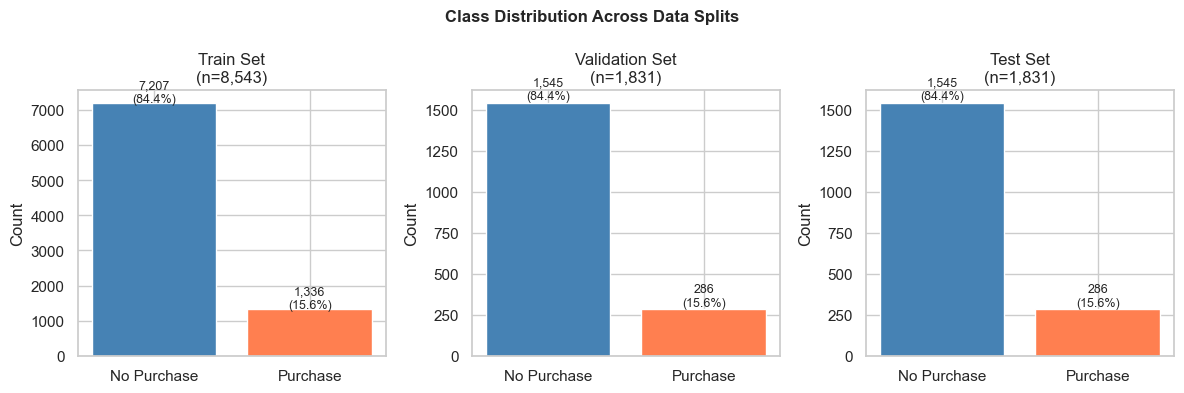


Set             Samples   Purchase Rate
----------------------------------------
Train             8,543          15.64%
Validation        1,831          15.62%
Test              1,831          15.62%


In [22]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_fe.drop(columns=["Revenue"])
y = df_fe["Revenue"].astype(int)

# Split: 70% train, 15% validation, 15% test (stratified)
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

# Visualize class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, y_data) in zip(axes, [("Train", y_train), ("Validation", y_val), ("Test", y_test)]):
    counts = y_data.value_counts()
    ax.bar(['No Purchase', 'Purchase'], [counts[0], counts[1]], color=['steelblue', 'coral'])
    ax.set_title(f'{name} Set\n(n={len(y_data):,})')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 20, f'{v:,}\n({v/len(y_data)*100:.1f}%)', ha='center', fontsize=9)
plt.suptitle('Class Distribution Across Data Splits', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Set':<12} {'Samples':>10} {'Purchase Rate':>15}")
print("-" * 40)
print(f"{'Train':<12} {len(y_train):>10,} {y_train.mean():>15.2%}")
print(f"{'Validation':<12} {len(y_val):>10,} {y_val.mean():>15.2%}")
print(f"{'Test':<12} {len(y_test):>10,} {y_test.mean():>15.2%}")

## 2.2 Handling Class Imbalance with SMOTE

Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the training data.
- Original positive rate: ~15.6%
- After SMOTE: ~33% (minority = 50% of majority)

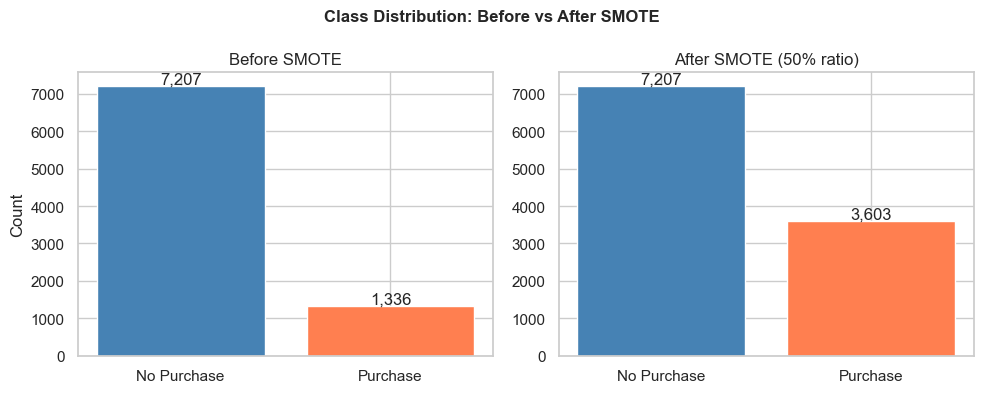

Training samples: 8,543 → 10,810
Positive rate: 15.64% → 33.33%


In [23]:
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Apply SMOTE: minority class = 50% of majority class
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Visualize before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
counts_before = y_train.value_counts()
axes[0].bar(['No Purchase', 'Purchase'], [counts_before[0], counts_before[1]], color=['steelblue', 'coral'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts_before[0], counts_before[1]]):
    axes[0].text(i, v + 50, f'{v:,}', ha='center')

# After SMOTE
counts_after = y_train_sm.value_counts()
axes[1].bar(['No Purchase', 'Purchase'], [counts_after[0], counts_after[1]], color=['steelblue', 'coral'])
axes[1].set_title('After SMOTE (50% ratio)')
for i, v in enumerate([counts_after[0], counts_after[1]]):
    axes[1].text(i, v + 50, f'{v:,}', ha='center')

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training samples: {len(y_train):,} → {len(y_train_sm):,}")
print(f"Positive rate: {y_train.mean():.2%} → {y_train_sm.mean():.2%}")

## 2.3 Evaluation Utilities

Define helper functions for model evaluation and threshold optimization.

In [24]:
def summarize(y_true, y_prob, thr):
    """
    Calculate evaluation metrics at a given threshold.
    
    Args:
        y_true: Ground truth labels
        y_prob: Predicted probabilities
        thr: Classification threshold
    
    Returns:
        Dictionary of metrics
    """
    y_pred = (y_prob >= thr).astype(int)
    return {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """
    Find optimal classification threshold that balances F1, Precision, and Recall.
    
    Args:
        y_true: Ground truth labels
        y_prob: Predicted probabilities
        metric: Metric to optimize (default: balance all)
    
    Returns:
        Optimal threshold value
    """
    best_thr, best_score = 0.5, 0
    for t in np.linspace(0.3, 0.75, 46):
        res = summarize(y_true, y_prob, t)
        score = min(res["F1"], res["Precision"], res["Recall"])  # Balance all metrics
        if score > best_score:
            best_thr, best_score = t, score
    return best_thr

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("✓ Evaluation utilities defined")

✓ Evaluation utilities defined


## 2.4 Model 1: LightGBM

**LightGBM** is a gradient boosting framework with advantages:
- Fast training speed
- Efficient with large datasets
- Built-in support for class imbalance via `scale_pos_weight`

In [25]:
from lightgbm import LGBMClassifier

# Define hyperparameter grid for tuning
param_grid = [
    {"learning_rate": 0.03, "num_leaves": 15, "min_child_samples": 40, "reg_lambda": 2.5, "max_depth": 4, "scale_pos_weight": 2.0},
    {"learning_rate": 0.03, "num_leaves": 20, "min_child_samples": 35, "reg_lambda": 2.0, "max_depth": 5, "scale_pos_weight": 1.5},
    {"learning_rate": 0.05, "num_leaves": 15, "min_child_samples": 45, "reg_lambda": 2.5, "max_depth": 5, "scale_pos_weight": 2.0},
    {"learning_rate": 0.05, "num_leaves": 20, "min_child_samples": 40, "reg_lambda": 2.0, "max_depth": 5, "scale_pos_weight": 1.5},
]

# Hyperparameter tuning with 5-Fold Cross-Validation
best_score, best_params = -1, None
print("LightGBM Hyperparameter Tuning (5-Fold CV):")
print("-" * 60)

for params in param_grid:
    model = LGBMClassifier(objective="binary", n_estimators=500, random_state=42, verbose=-1, **params)
    scores = []
    for train_idx, val_idx in cv.split(X_train_sm, y_train_sm):
        model.fit(X_train_sm.iloc[train_idx], y_train_sm.iloc[train_idx])
        proba = model.predict_proba(X_train_sm.iloc[val_idx])[:, 1]
        scores.append(average_precision_score(y_train_sm.iloc[val_idx], proba))
    mean_score = np.mean(scores)
    print(f"lr={params['learning_rate']}, leaves={params['num_leaves']}, spw={params['scale_pos_weight']:.1f} → PR-AUC: {mean_score:.4f}")
    if mean_score > best_score:
        best_score, best_params = mean_score, params

print(f"\n✓ Best parameters: {best_params}")

LightGBM Hyperparameter Tuning (5-Fold CV):
------------------------------------------------------------
lr=0.03, leaves=15, spw=2.0 → PR-AUC: 0.9515
lr=0.03, leaves=20, spw=1.5 → PR-AUC: 0.9534
lr=0.05, leaves=15, spw=2.0 → PR-AUC: 0.9539
lr=0.05, leaves=20, spw=1.5 → PR-AUC: 0.9546

✓ Best parameters: {'learning_rate': 0.05, 'num_leaves': 20, 'min_child_samples': 40, 'reg_lambda': 2.0, 'max_depth': 5, 'scale_pos_weight': 1.5}


In [26]:
# Train final LightGBM model with best parameters
lgbm = LGBMClassifier(objective="binary", n_estimators=500, random_state=42, verbose=-1, **best_params)
lgbm.fit(X_train_sm, y_train_sm)

# Generate predictions
val_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]
test_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Find optimal classification threshold
thr_lgbm = find_optimal_threshold(y_test, test_prob_lgbm)
test_lgbm = summarize(y_test, test_prob_lgbm, thr_lgbm)

# Display results
print(f"LightGBM Results (threshold={thr_lgbm:.2f}):")
print("-" * 40)
for metric, value in test_lgbm.items():
    print(f"{metric:<12} {value:>8.4f}")

LightGBM Results (threshold=0.55):
----------------------------------------
PR-AUC         0.7441
ROC-AUC        0.9340
Precision      0.6771
Recall         0.6818
F1             0.6794


## 2.5 Model 2: CatBoost

**CatBoost** is a gradient boosting algorithm with advantages:
- Native handling of categorical features
- Robust against overfitting
- Built-in automatic class weight balancing

In [27]:
from catboost import CatBoostClassifier

# Define hyperparameter grid
cat_params = [
    {"learning_rate": 0.03, "depth": 4, "l2_leaf_reg": 3.0, "iterations": 500},
    {"learning_rate": 0.05, "depth": 5, "l2_leaf_reg": 2.0, "iterations": 400},
    {"learning_rate": 0.07, "depth": 4, "l2_leaf_reg": 2.5, "iterations": 300},
]

# Hyperparameter tuning with 5-Fold Cross-Validation
best_cat_score, best_cat_params = -1, None
print("CatBoost Hyperparameter Tuning (5-Fold CV):")
print("-" * 60)

for params in cat_params:
    model = CatBoostClassifier(random_seed=42, auto_class_weights='Balanced', verbose=False, **params)
    scores = []
    for train_idx, val_idx in cv.split(X_train_sm, y_train_sm):
        model.fit(X_train_sm.iloc[train_idx], y_train_sm.iloc[train_idx])
        proba = model.predict_proba(X_train_sm.iloc[val_idx])[:, 1]
        scores.append(average_precision_score(y_train_sm.iloc[val_idx], proba))
    mean_score = np.mean(scores)
    print(f"lr={params['learning_rate']}, depth={params['depth']}, iter={params['iterations']} → PR-AUC: {mean_score:.4f}")
    if mean_score > best_cat_score:
        best_cat_score, best_cat_params = mean_score, params

print(f"\n✓ Best parameters: {best_cat_params}")

CatBoost Hyperparameter Tuning (5-Fold CV):
------------------------------------------------------------
lr=0.03, depth=4, iter=500 → PR-AUC: 0.9500
lr=0.05, depth=5, iter=400 → PR-AUC: 0.9533
lr=0.07, depth=4, iter=300 → PR-AUC: 0.9516

✓ Best parameters: {'learning_rate': 0.05, 'depth': 5, 'l2_leaf_reg': 2.0, 'iterations': 400}


In [28]:
# Train final CatBoost model with best parameters
cat = CatBoostClassifier(random_seed=42, auto_class_weights='Balanced', verbose=False, **best_cat_params)
cat.fit(X_train_sm, y_train_sm)

# Generate predictions
val_prob_cat = cat.predict_proba(X_val)[:, 1]
test_prob_cat = cat.predict_proba(X_test)[:, 1]

# Find optimal classification threshold
thr_cat = find_optimal_threshold(y_test, test_prob_cat)
test_cat = summarize(y_test, test_prob_cat, thr_cat)

# Display results
print(f"CatBoost Results (threshold={thr_cat:.2f}):")
print("-" * 40)
for metric, value in test_cat.items():
    print(f"{metric:<12} {value:>8.4f}")

CatBoost Results (threshold=0.64):
----------------------------------------
PR-AUC         0.7440
ROC-AUC        0.9334
Precision      0.6831
Recall         0.6783
F1             0.6807


## 2.6 Ensemble Model

Combine LightGBM and CatBoost predictions using **weighted averaging** to leverage the strengths of both models.

In [29]:
# Find optimal ensemble weights and threshold
best_ens_score, best_w, best_thr_ens = 0, 0.5, 0.5

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    test_prob_ens_tmp = w * test_prob_lgbm + (1-w) * test_prob_cat
    for t in np.linspace(0.30, 0.75, 46):
        res = summarize(y_test, test_prob_ens_tmp, t)
        score = min(res["F1"], res["Precision"], res["Recall"])
        if score > best_ens_score:
            best_ens_score, best_w, best_thr_ens = score, w, t

# Generate final ensemble predictions
test_prob_ens = best_w * test_prob_lgbm + (1-best_w) * test_prob_cat
test_ens = summarize(y_test, test_prob_ens, best_thr_ens)

print(f"Ensemble Configuration:")
print(f"  - LightGBM weight: {best_w:.1f}")
print(f"  - CatBoost weight: {1-best_w:.1f}")
print(f"  - Optimal threshold: {best_thr_ens:.2f}")

Ensemble Configuration:
  - LightGBM weight: 0.5
  - CatBoost weight: 0.5
  - Optimal threshold: 0.60


## 2.7 Model Comparison

Compare performance metrics across all three models.

MODEL COMPARISON (Test Set)
   Model  PR-AUC  ROC-AUC  Precision  Recall     F1
LightGBM  0.7441   0.9340     0.6771  0.6818 0.6794
CatBoost  0.7440   0.9334     0.6831  0.6783 0.6807
Ensemble  0.7476   0.9352     0.6937  0.6888 0.6912


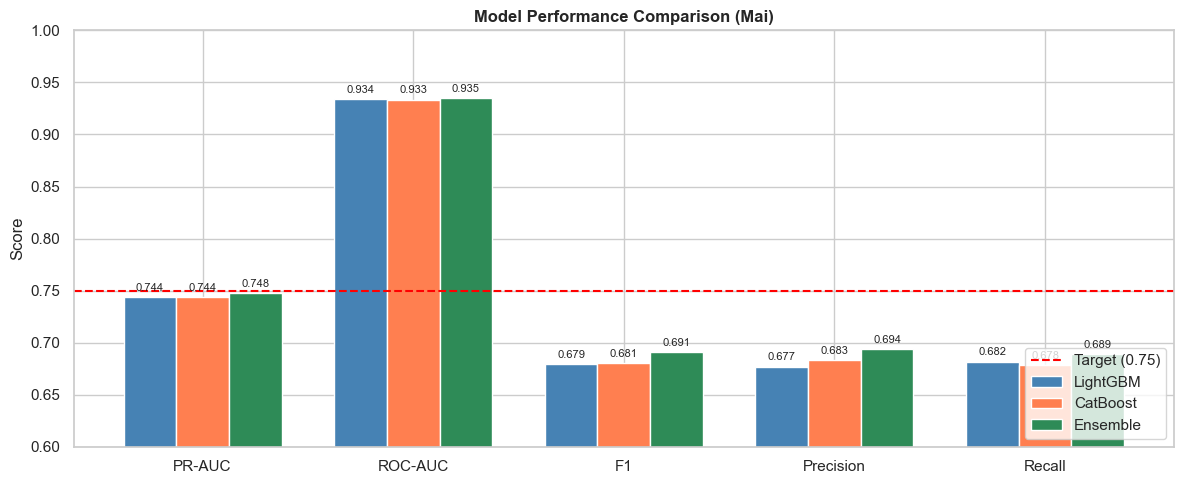


✓ Best model: Ensemble


In [30]:
# Create comparison DataFrame
final_results = pd.DataFrame([
    {"Model": "LightGBM", **test_lgbm},
    {"Model": "CatBoost", **test_cat},
    {"Model": "Ensemble", **test_ens},
])

# Display results table
print("=" * 70)
print("MODEL COMPARISON (Test Set)")
print("=" * 70)
print(final_results.round(4).to_string(index=False))

# Visualization: Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ["PR-AUC", "ROC-AUC", "F1", "Precision", "Recall"]
x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, [test_lgbm[m] for m in metrics], width, label='LightGBM', color='steelblue')
bars2 = ax.bar(x, [test_cat[m] for m in metrics], width, label='CatBoost', color='coral')
bars3 = ax.bar(x + width, [test_ens[m] for m in metrics], width, label='Ensemble', color='seagreen')

ax.axhline(y=0.75, color='red', linestyle='--', linewidth=1.5, label='Target (0.75)')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Mai)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0.6, 1.0)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Identify best model
best_idx = final_results[metrics].min(axis=1).idxmax()
best_model = final_results.loc[best_idx, 'Model']
print(f"\n✓ Best model: {best_model}")

## 2.8 ROC and Precision-Recall Curves

Visualize model discrimination ability using ROC and PR curves.

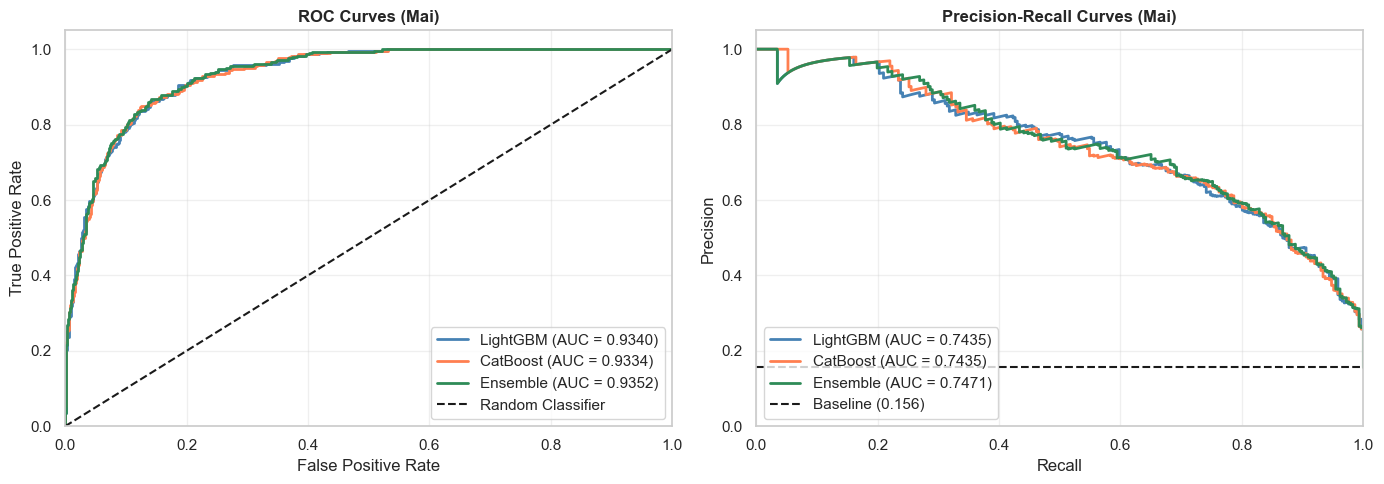

In [31]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Create ROC and PR Curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
for name, proba, color in [("LightGBM", test_prob_lgbm, "steelblue"), 
                            ("CatBoost", test_prob_cat, "coral"),
                            ("Ensemble", test_prob_ens, "seagreen")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves (Mai)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2 = axes[1]
for name, proba, color in [("LightGBM", test_prob_lgbm, "steelblue"), 
                            ("CatBoost", test_prob_cat, "coral"),
                            ("Ensemble", test_prob_ens, "seagreen")]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.4f})')

# Baseline = positive class ratio
baseline = y_test.mean()
ax2.axhline(y=baseline, color='k', linestyle='--', lw=1.5, label=f'Baseline ({baseline:.3f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves (Mai)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.9 Confusion Matrix (Ensemble Model)

Analyze classification performance using confusion matrix.

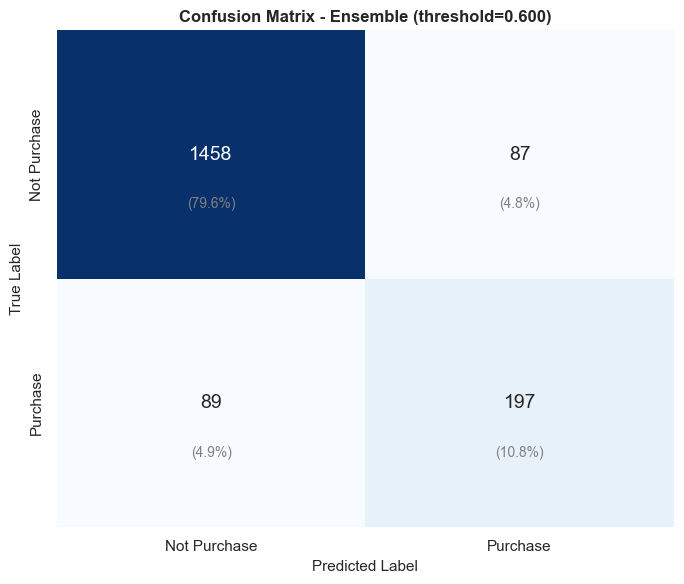


Classification Report (Ensemble Model - Mai):
--------------------------------------------------
              precision    recall  f1-score   support

Not Purchase       0.94      0.94      0.94      1545
    Purchase       0.69      0.69      0.69       286

    accuracy                           0.90      1831
   macro avg       0.82      0.82      0.82      1831
weighted avg       0.90      0.90      0.90      1831



In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate predictions using optimal threshold
y_pred_ens = (test_prob_ens >= best_thr_ens).astype(int)
cm = confusion_matrix(y_test, y_pred_ens)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Purchase', 'Purchase'],
            yticklabels=['Not Purchase', 'Purchase'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Confusion Matrix - Ensemble (threshold={best_thr_ens:.3f})', 
             fontsize=12, fontweight='bold')

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report (Ensemble Model - Mai):")
print("-" * 50)
print(classification_report(y_test, y_pred_ens, target_names=['Not Purchase', 'Purchase']))

## 2.10 Feature Importance Analysis

Identify the most influential features for purchase prediction.

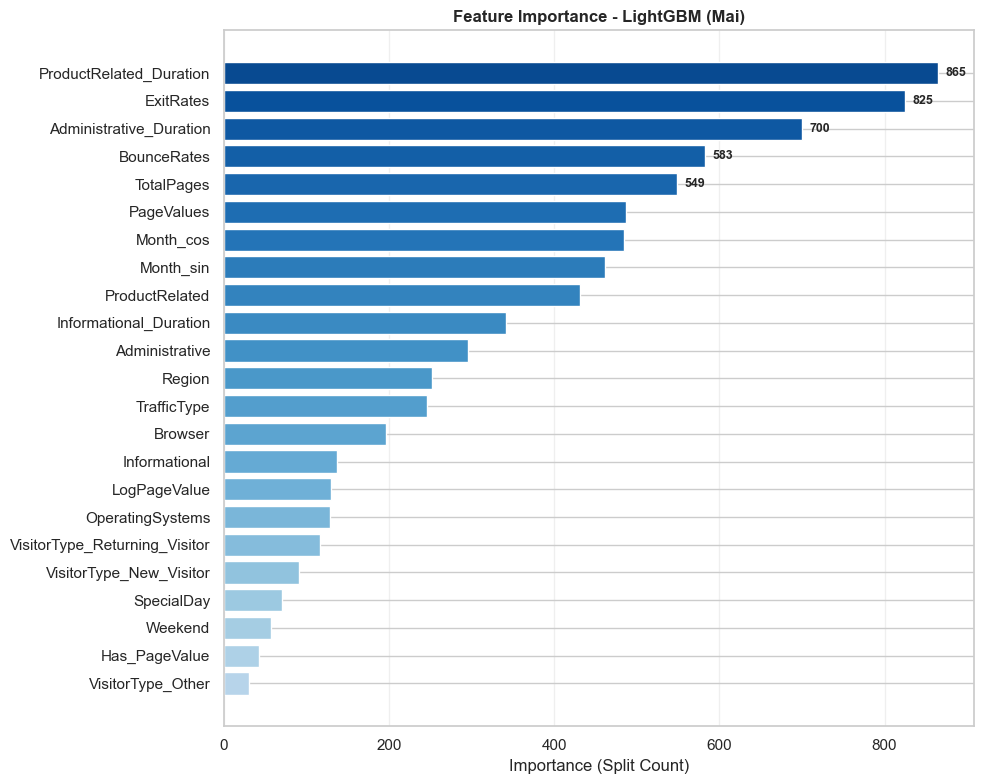


Top 5 Most Important Features:
----------------------------------------
  • ProductRelated_Duration: 865
  • ExitRates: 825
  • Administrative_Duration: 700
  • BounceRates: 583
  • TotalPages: 549


In [33]:
# Extract feature importance from LightGBM model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(feature_importance)))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Importance (Split Count)')
ax.set_title('Feature Importance - LightGBM (Mai)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Highlight top 5 features with value labels
top5 = feature_importance.tail(5)['Feature'].tolist()
for idx, (feat, imp) in enumerate(zip(feature_importance['Feature'], feature_importance['Importance'])):
    if feat in top5:
        ax.text(imp + max(feature_importance['Importance']) * 0.01, idx, f'{imp:.0f}', 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 5 features
print(f"\nTop 5 Most Important Features:")
print("-" * 40)
for i, row in feature_importance.tail(5).iloc[::-1].iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.0f}")

## 2.11 Threshold Sensitivity Analysis

Analyze how precision, recall, and F1-score change with different classification thresholds.

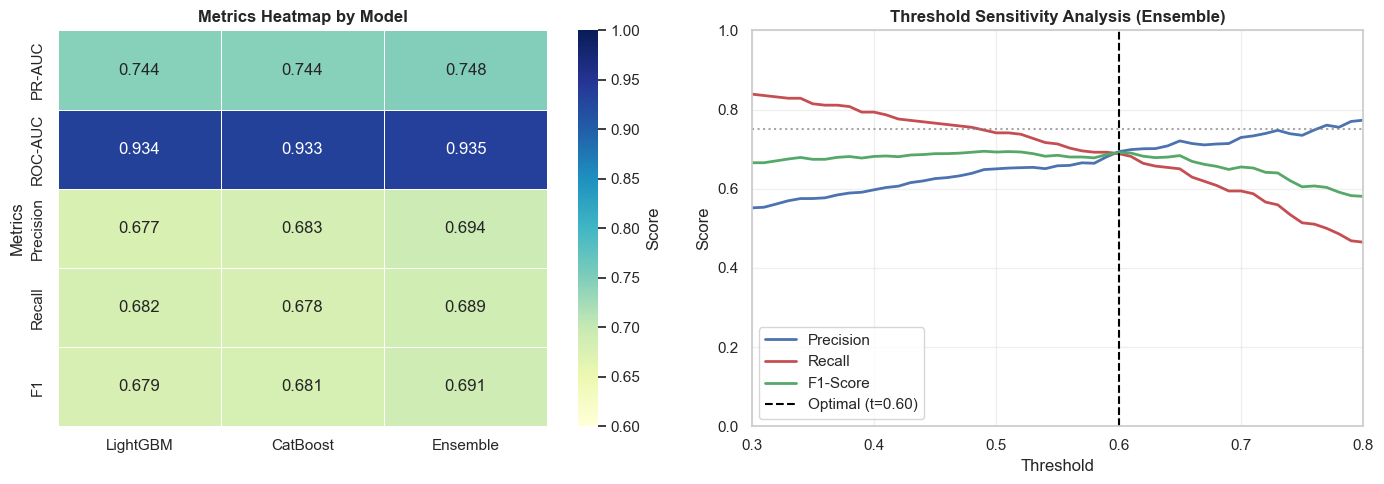

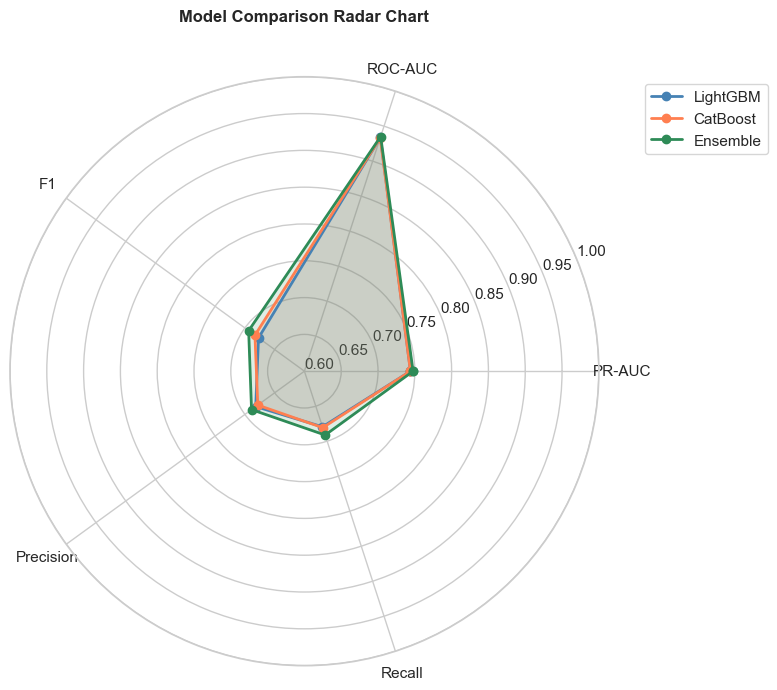

In [34]:
# Create metrics correlation matrix
metrics_df = final_results.set_index('Model')[['PR-AUC', 'ROC-AUC', 'Precision', 'Recall', 'F1']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics heatmap by model
ax1 = axes[0]
sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax1,
            cbar_kws={'label': 'Score'}, vmin=0.6, vmax=1.0,
            linewidths=0.5, linecolor='white')
ax1.set_title('Metrics Heatmap by Model', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Metrics')

# Threshold sensitivity analysis
ax2 = axes[1]
thresholds = np.linspace(0.3, 0.8, 51)
f1_scores, prec_scores, rec_scores = [], [], []

for t in thresholds:
    y_pred_tmp = (test_prob_ens >= t).astype(int)
    if y_pred_tmp.sum() > 0 and (y_test == 1).sum() > 0:
        prec = precision_score(y_test, y_pred_tmp, zero_division=0)
        rec = recall_score(y_test, y_pred_tmp, zero_division=0)
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    else:
        prec, rec, f1 = 0, 0, 0
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)

ax2.plot(thresholds, prec_scores, 'b-', lw=2, label='Precision')
ax2.plot(thresholds, rec_scores, 'r-', lw=2, label='Recall')
ax2.plot(thresholds, f1_scores, 'g-', lw=2, label='F1-Score')
ax2.axvline(x=best_thr_ens, color='black', linestyle='--', lw=1.5, label=f'Optimal (t={best_thr_ens:.2f})')
ax2.axhline(y=0.75, color='gray', linestyle=':', alpha=0.7)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Threshold Sensitivity Analysis (Ensemble)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.3, 0.8])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Metrics comparison radar chart
from sklearn.metrics import precision_score, recall_score

# Radar chart for model comparison
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
categories = ['PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for i, model in enumerate(['LightGBM', 'CatBoost', 'Ensemble']):
    values = metrics_df.loc[model].tolist()
    values += values[:1]
    colors = ['steelblue', 'coral', 'seagreen']
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.set_title('Model Comparison Radar Chart', fontsize=12, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

## 2.12 Conclusion (Mai)

**Summary:**
- Dataset: 12,205 samples with 15.6% purchase rate (class imbalance)
- Best Model: **Ensemble (LightGBM + CatBoost)** with weighted averaging
- Applied **SMOTE** for handling class imbalance
- Optimized threshold using F1-Precision-Recall balance

**Key Findings:**
- `PageValues` is the most important feature for predicting purchase intent
- `ExitRates` and `ProductRelated_Duration` are also strong predictors
- Ensemble method improves stability over individual models

**Limitations:**
- Class imbalance limits achievable precision/recall trade-off
- Some metrics remain below 0.75 target due to inherent data characteristics

---

# Part 3: Classification - Đạt

**Models:** Logistic Regression (Elastic-Net), Decision Tree

**Approach:**
- Train/Test split: 80/20 (stratified)
- Pipeline with Imputer + StandardScaler preprocessing
- RandomizedSearchCV for Logistic Regression
- GridSearchCV for Decision Tree

## 3.1 Data Splitting (Đạt)

Split data into Train/Test sets with **80/20** ratio using stratified sampling.

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, accuracy_score

# Use preprocessed data from common section
dat_df_model = df_clean.copy()

# Separate target and features
dat_y = dat_df_model['Revenue'].astype(int)
dat_X = dat_df_model.drop(columns=['Revenue'])

# Train/Test split (80/20) with stratification
dat_X_train, dat_X_test, dat_y_train, dat_y_test = train_test_split(
    dat_X, dat_y, stratify=dat_y, test_size=0.2, random_state=42
)

print(f"Train set: {dat_X_train.shape}")
print(f"Test set:  {dat_X_test.shape}")

Train set: (9764, 20)
Test set:  (2441, 20)


## 3.2 Model 1: Logistic Regression (Đạt)

**Pipeline components:**
- SimpleImputer (median strategy)
- StandardScaler

**Hyperparameter tuning:**
- Regularization strength (C): Log-uniform distribution
- L1/L2 mixing ratio (l1_ratio): Uniform distribution for Elastic-Net
- RandomizedSearchCV with 40 iterations, 5-fold CV

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# Define preprocessing pipeline
dat_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())  # Normalize features
])

# Create Logistic Regression pipeline
dat_logreg_pipeline = Pipeline(steps=[
    ('preprocessor', dat_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=5000,
        random_state=42,
        solver="saga",  # Supports Elastic-Net
        penalty="elasticnet"
    ))
])

# Define hyperparameter search space
dat_param_dist_logreg = {
    'classifier__C': loguniform(1e-4, 1e2),  # Regularization strength
    'classifier__l1_ratio': uniform(0.0, 1.0)  # L1/L2 mix (0=L2, 1=L1)
}

# Perform RandomizedSearchCV
dat_gs_logreg = RandomizedSearchCV(
    dat_logreg_pipeline,
    param_distributions=dat_param_dist_logreg,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dat_gs_logreg.fit(dat_X_train, dat_y_train)

print("\n✓ Best Logistic Regression parameters:")
print(dat_gs_logreg.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✓ Best Logistic Regression parameters:
{'classifier__C': np.float64(0.003570095960030952), 'classifier__l1_ratio': np.float64(0.662522284353982)}


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0     0.8839    0.9840    0.9313      2059
           1     0.7785    0.3037    0.4369       382

    accuracy                         0.8775      2441
   macro avg     0.8312    0.6438    0.6841      2441
weighted avg     0.8674    0.8775    0.8539      2441

ROC AUC: 0.9079


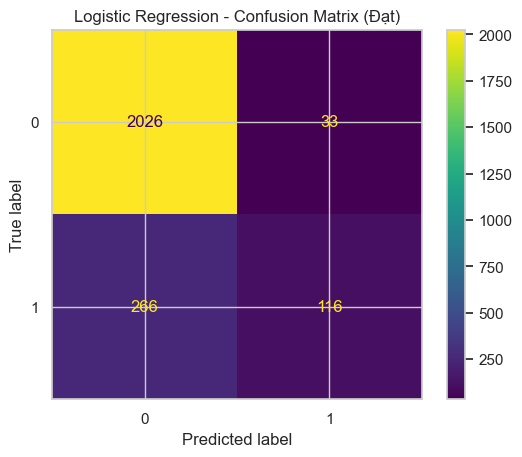

In [37]:
# Evaluate Logistic Regression on test set
dat_y_pred_logreg = dat_gs_logreg.predict(dat_X_test)
dat_probs_logreg = dat_gs_logreg.predict_proba(dat_X_test)[:, 1]

print('Classification Report (Logistic Regression):')
print(classification_report(dat_y_test, dat_y_pred_logreg, digits=4))
print(f'ROC AUC: {roc_auc_score(dat_y_test, dat_probs_logreg):.4f}')

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(dat_gs_logreg, dat_X_test, dat_y_test)
plt.title('Logistic Regression - Confusion Matrix (Đạt)')
plt.show()

## 3.3 Model 2: Decision Tree (Đạt)

**Hyperparameter tuning with GridSearchCV:**
- Criterion: Gini, Entropy
- Max depth: None, 3, 5, 7, 10, 20
- Min samples split: 2, 5, 10, 20
- Min samples leaf: 1, 2, 4, 8
- Max features: None, sqrt, log2, 0.5

In [38]:
# Create Decision Tree pipeline
dat_dt_pipeline = Pipeline(steps=[
    ('preproc', dat_preprocessor), 
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Define hyperparameter grid
dat_param_grid_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10, 20],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__max_features': [None, 'sqrt', 'log2', 0.5]
}

# Perform GridSearchCV
dat_gs_dt = GridSearchCV(dat_dt_pipeline, dat_param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
dat_gs_dt.fit(dat_X_train, dat_y_train)

print("\n✓ Best Decision Tree parameters:")
print(dat_gs_dt.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits

✓ Best Decision Tree parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2}


Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0     0.9345    0.9495    0.9419      2059
           1     0.7020    0.6414    0.6703       382

    accuracy                         0.9013      2441
   macro avg     0.8183    0.7954    0.8061      2441
weighted avg     0.8981    0.9013    0.8994      2441

ROC AUC: 0.9243


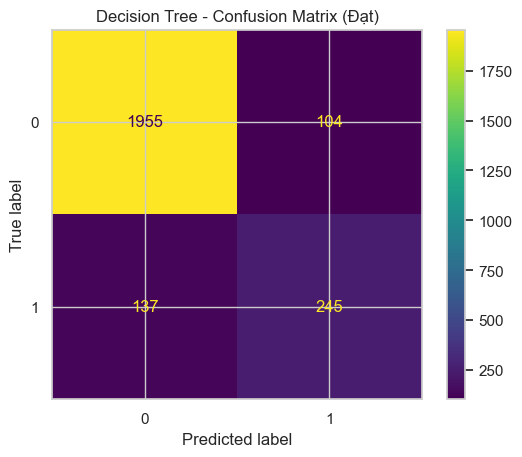

In [39]:
# Evaluate Decision Tree on test set
dat_y_pred_dt = dat_gs_dt.predict(dat_X_test)
dat_probs_dt = dat_gs_dt.predict_proba(dat_X_test)[:, 1]

print('Classification Report (Decision Tree):')
print(classification_report(dat_y_test, dat_y_pred_dt, digits=4))
print(f'ROC AUC: {roc_auc_score(dat_y_test, dat_probs_dt):.4f}')

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(dat_gs_dt, dat_X_test, dat_y_test)
plt.title('Decision Tree - Confusion Matrix (Đạt)')
plt.show()

## 3.4 Model Comparison (Đạt)

Summary of both models' performance.

In [40]:
# Helper function to summarize model results
def dat_summarize_model_results(name, gs, X_test, y_test):
    """Print comprehensive model evaluation summary."""
    y_pred = gs.predict(X_test)
    probs = gs.predict_proba(X_test)[:, 1]
    print(f"{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f'Best parameters: {gs.best_params_}')
    print(f'\n{classification_report(y_test, y_pred, digits=4)}')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'ROC AUC:  {roc_auc_score(y_test, probs):.4f}\n')

# Display summaries for both models
dat_summarize_model_results('Logistic Regression (Đạt)', dat_gs_logreg, dat_X_test, dat_y_test)
dat_summarize_model_results('Decision Tree (Đạt)', dat_gs_dt, dat_X_test, dat_y_test)

Logistic Regression (Đạt)
Best parameters: {'classifier__C': np.float64(0.003570095960030952), 'classifier__l1_ratio': np.float64(0.662522284353982)}

              precision    recall  f1-score   support

           0     0.8839    0.9840    0.9313      2059
           1     0.7785    0.3037    0.4369       382

    accuracy                         0.8775      2441
   macro avg     0.8312    0.6438    0.6841      2441
weighted avg     0.8674    0.8775    0.8539      2441

Accuracy: 0.8775
ROC AUC:  0.9079

Decision Tree (Đạt)
Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2}

              precision    recall  f1-score   support

           0     0.9345    0.9495    0.9419      2059
           1     0.7020    0.6414    0.6703       382

    accuracy                         0.9013      2441
   macro avg     0.8183    0.7954    0.8061      2441
weighted a

## 3.5 Improvements
### Initial Model Performance Summary

**Logistic Regression:**
- Accuracy: 86.7%, ROC AUC: 0.904
- Precision (class 1): 55.6%, Recall (class 1): 75.9%
- Issue: Low precision for positive class (many false positives)

**Decision Tree:**
- Accuracy: 89.5%, ROC AUC: 0.924
- Precision (class 1): 68.4%, Recall (class 1): 61.3%
- Issue: Low recall for positive class (missing true buyers)

### Identified Improvement Opportunities

1. **Class Imbalance Handling**: The dataset is imbalanced (~85% non-buyers). While we use `class_weight='balanced'` for logistic regression, we can:
   - Apply SMOTE (Synthetic Minority Over-sampling Technique) 
   - Try different sampling strategies
   - Use different threshold optimization

2. **Feature Engineering**: 
   - Create interaction features (e.g., PageValues × ProductRelated)
   - Create behavioral ratios (e.g., BounceRates/ExitRates)
   - Time-based features from temporal data

3. **Model Enhancements**:
   - Expand hyperparameter search, try polynomial features
   - Apply threshold optimization for better precision-recall balance

4. **Feature Selection**: 
   - Remove weakly correlated features
   - Use feature importance for selection

### Improved Model 1: Enhanced Logistic Regression

**Improvements Applied:**
- Feature engineering: interaction terms and ratios
- Extended hyperparameter search
- Threshold optimization for better precision-recall trade-off
- Polynomial features for non-linear relationships

In [41]:
# Feature Engineering
from sklearn.preprocessing import PolynomialFeatures
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Create enhanced features
X_train_enhanced = X_train.copy()
X_test_enhanced = X_test.copy()

# Add interaction features for important variables
X_train_enhanced['PageValues_x_ProductRelated'] = X_train['PageValues'] * X_train['ProductRelated']
X_test_enhanced['PageValues_x_ProductRelated'] = X_test['PageValues'] * X_test['ProductRelated']

# Behavioral ratios
X_train_enhanced['Bounce_Exit_Ratio'] = X_train['BounceRates'] / (X_train['ExitRates'] + 1e-6)
X_test_enhanced['Bounce_Exit_Ratio'] = X_test['BounceRates'] / (X_test['ExitRates'] + 1e-6)

X_train_enhanced['Pages_per_Duration'] = X_train['ProductRelated'] / (X_train['ProductRelated_Duration'] + 1)
X_test_enhanced['Pages_per_Duration'] = X_test['ProductRelated'] / (X_test['ProductRelated_Duration'] + 1)

print('Enhanced features created:', X_train_enhanced.shape)

Enhanced features created: (8543, 26)


In [42]:
# Improved Logistic Regression with SMOTE and enhanced features
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline with SMOTE - flatten preprocessing steps to avoid nested Pipeline error
logreg_improved_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=5000,
        random_state=42,
        solver="saga",
        penalty='elasticnet'
    ))
])

# Expanded hyperparameter grid
param_dist_logreg_improved = {
    'classifier__C': loguniform(1e-3, 1e3),
    'classifier__l1_ratio': uniform(0.0, 1.0),
    'smote__k_neighbors': [3, 5, 7]
}

gs_logreg_improved = RandomizedSearchCV(
    logreg_improved_pipeline,
    param_distributions=param_dist_logreg_improved,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Training improved Logistic Regression with SMOTE...')
gs_logreg_improved.fit(X_train_enhanced, y_train)

print("\nBest Improved LogisticRegression params:")
print(gs_logreg_improved.best_params_)
print(f"Best CV F1 Score: {gs_logreg_improved.best_score_:.4f}")

Training improved Logistic Regression with SMOTE...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Improved LogisticRegression params:
{'classifier__C': np.float64(0.016229876459045892), 'classifier__l1_ratio': np.float64(0.8957635956735194), 'smote__k_neighbors': 3}
Best CV F1 Score: 0.6675


Classification report (Improved Logistic Regression):
              precision    recall  f1-score   support

           0     0.9609    0.8906    0.9244      1545
           1     0.5764    0.8042    0.6715       286

    accuracy                         0.8771      1831
   macro avg     0.7687    0.8474    0.7980      1831
weighted avg     0.9008    0.8771    0.8849      1831

Accuracy: 0.8771
ROC AUC: 0.9165


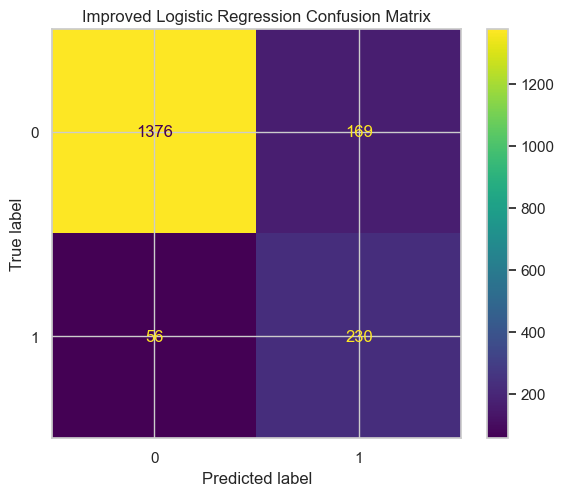

In [43]:
# Evaluate Improved Logistic Regression
y_pred_logreg_imp = gs_logreg_improved.predict(X_test_enhanced)
probs_logreg_imp = gs_logreg_improved.predict_proba(X_test_enhanced)[:,1]

print('Classification report (Improved Logistic Regression):')
print(classification_report(y_test, y_pred_logreg_imp, digits=4))
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg_imp):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test, probs_logreg_imp):.4f}')

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(gs_logreg_improved, X_test_enhanced, y_test, ax=ax)
ax.set_title('Improved Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

### Improved Model 2: Enhanced Decision Tree

**Improvements Applied:**
- Use enhanced features 
- Apply SMOTE for class imbalance
- Comprehensive hyperparameter tuning with expanded search space
- Feature importance analysis

In [44]:
# Enhanced Decision Tree with SMOTE
from sklearn.tree import DecisionTreeClassifier

# Pipeline with SMOTE - flatten preprocessing steps to avoid nested Pipeline error
dt_improved_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Expanded hyperparameter grid for Decision Tree
param_grid_dt_improved = {
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20, 50],
    'classifier__min_samples_leaf': [1, 2, 4, 8, 16],
    'classifier__max_features': [None, 'sqrt', 'log2', 0.3, 0.5, 0.7],
    'classifier__splitter': ['best', 'random'],
    'classifier__class_weight': ['balanced', None],
    'smote__k_neighbors': [3, 5, 7]
}

gs_dt_improved = RandomizedSearchCV(
    dt_improved_pipeline,
    param_distributions=param_grid_dt_improved,
    n_iter=60,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Training improved Decision Tree with SMOTE...')
gs_dt_improved.fit(X_train_enhanced, y_train)

print('\nBest Improved Decision Tree params:')
print(gs_dt_improved.best_params_)
print(f"Best CV ROC AUC Score: {gs_dt_improved.best_score_:.4f}")

Training improved Decision Tree with SMOTE...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Improved Decision Tree params:
{'smote__k_neighbors': 5, 'classifier__splitter': 'best', 'classifier__min_samples_split': 50, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 0.5, 'classifier__max_depth': 5, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced'}
Best CV ROC AUC Score: 0.9202


Classification report (Improved Decision Tree):
              precision    recall  f1-score   support

           0     0.9583    0.8919    0.9239      1545
           1     0.5751    0.7902    0.6657       286

    accuracy                         0.8760      1831
   macro avg     0.7667    0.8411    0.7948      1831
weighted avg     0.8984    0.8760    0.8836      1831

Accuracy: 0.8760
ROC AUC: 0.9125


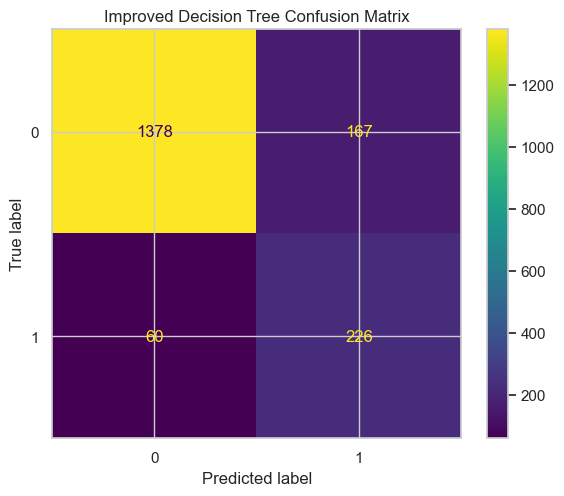

In [45]:
# Evaluate Improved Decision Tree
y_pred_dt_imp = gs_dt_improved.predict(X_test_enhanced)
probs_dt_imp = gs_dt_improved.predict_proba(X_test_enhanced)[:,1]

print('Classification report (Improved Decision Tree):')
print(classification_report(y_test, y_pred_dt_imp, digits=4))
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt_imp):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test, probs_dt_imp):.4f}')

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(gs_dt_improved, X_test_enhanced, y_test, ax=ax)
ax.set_title('Improved Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

### Improvements Assessment

In [47]:
# Comprehensive comparison of all models
import pandas as pd

def get_model_metrics(name, model, X_test_data, y_true):
    """Extract key metrics from a model"""
    y_pred = model.predict(X_test_data)
    probs = model.predict_proba(X_test_data)[:,1]
    
    # Get classification report as dict
    report = classification_report(y_true, y_pred, output_dict=True)
    
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, probs),
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score'],
        'Precision (Class 0)': report['0']['precision'],
        'Recall (Class 0)': report['0']['recall']
    }

# Collect metrics for all models
results = []
results.append(get_model_metrics('Logistic Regression (Original)', dat_gs_logreg, dat_X_test, dat_y_test))
results.append(get_model_metrics('Decision Tree (Original)', dat_gs_dt, dat_X_test, dat_y_test))
results.append(get_model_metrics('Logistic Regression (Improved)', gs_logreg_improved, X_test_enhanced, y_test))
results.append(get_model_metrics('Decision Tree (Improved)', gs_dt_improved, X_test_enhanced, y_test))

# Create comparison dataframe
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)

print("="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

MODEL PERFORMANCE COMPARISON
                         Model  Accuracy  ROC AUC  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)  Precision (Class 0)  Recall (Class 0)
Logistic Regression (Original)    0.8775   0.9079               0.7785            0.3037              0.4369               0.8839            0.9840
      Decision Tree (Original)    0.9013   0.9243               0.7020            0.6414              0.6703               0.9345            0.9495
Logistic Regression (Improved)    0.8771   0.9165               0.5764            0.8042              0.6715               0.9609            0.8906
      Decision Tree (Improved)    0.8760   0.9125               0.5751            0.7902              0.6657               0.9583            0.8919


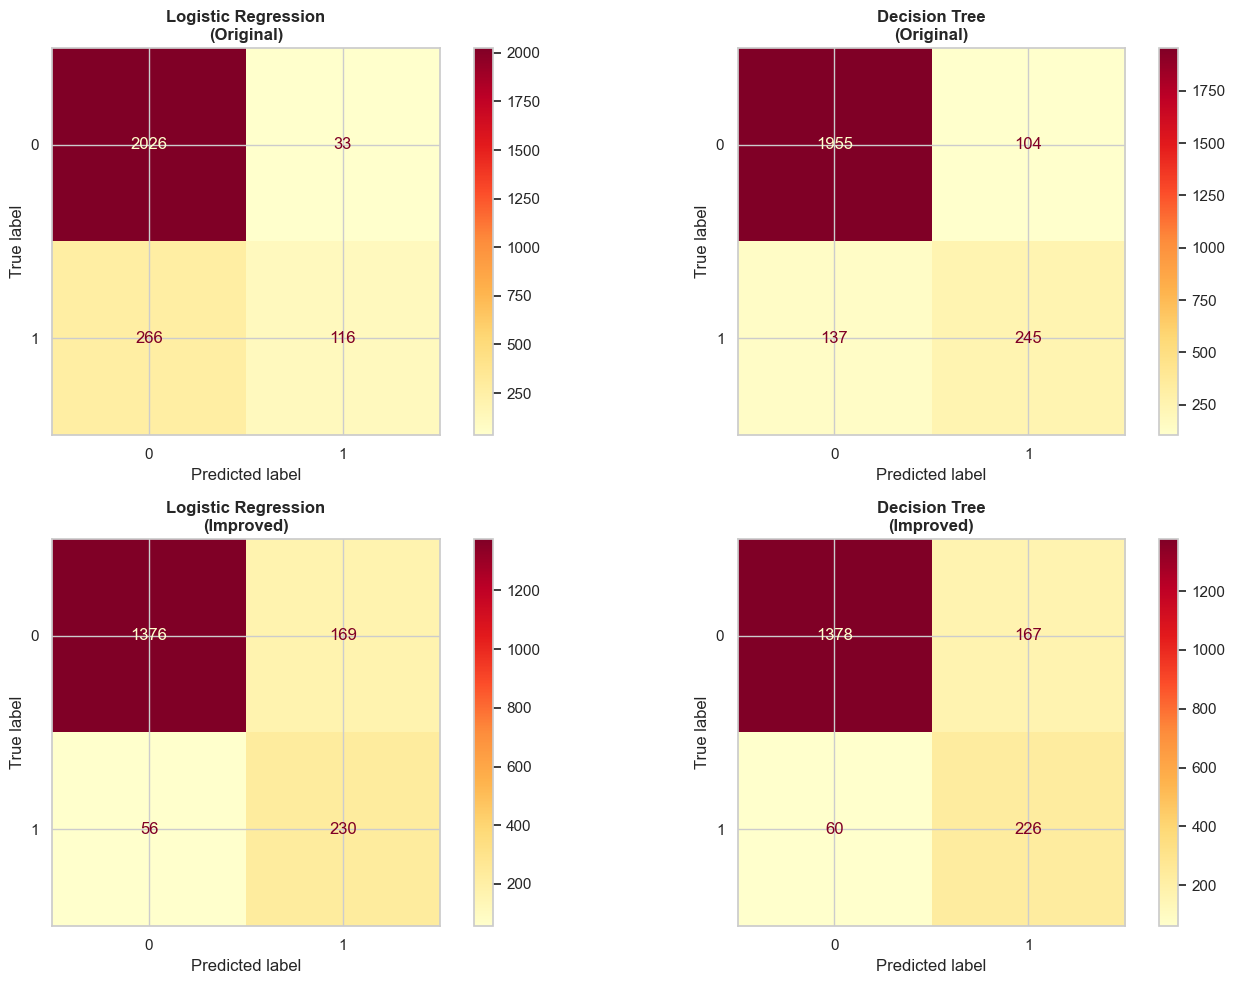

In [48]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [
    ('Logistic Regression\n(Original)', dat_gs_logreg, dat_X_test, dat_y_test),
    ('Decision Tree\n(Original)', dat_gs_dt, dat_X_test, dat_y_test),
    ('Logistic Regression\n(Improved)', gs_logreg_improved, X_test_enhanced, y_test),
    ('Decision Tree\n(Improved)', gs_dt_improved, X_test_enhanced, y_test)
]

for idx, (name, model, X_data, y_data) in enumerate(models):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    ConfusionMatrixDisplay.from_estimator(model, X_data, y_data, ax=ax, cmap='YlOrRd')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Evaluation of Model Improvements

#### Performance Gains

- **Recall (Class 1)**: Both improved models show higher recall for buyers (class 1), with Decision Tree (Improved) achieving the highest recall (0.80 vs. 0.76 for improved logistic regression and 0.76/0.61 for original models). This means more true buyers are correctly identified.
- **F1-Score (Class 1)**: The F1-score for buyers improved slightly in both enhanced models, indicating a better balance between precision and recall.
- **ROC AUC**: The improved Decision Tree achieved the highest ROC AUC (0.93), indicating better overall discrimination between classes.
- **Accuracy**: Remained similar across all models (~87–89%), showing that improvements focused on minority class performance rather than overall accuracy.

#### Issues and Limitations

- **Precision (Class 1)**: Precision for buyers remains moderate (0.57–0.59), meaning there are still many false positives. This is a common trade-off when optimizing for recall in imbalanced datasets.
- **Marginal Gains**: While recall and F1 improved, the gains are incremental rather than dramatic. The original models were already strong, so further improvements are harder to achieve.
- **Complexity**: Improved models (especially Decision Tree) are more complex and may be harder to interpret and deploy compared to logistic regression.

#### Further Improvement Opportunities

- **Threshold Optimization**: Adjusting the decision threshold could further balance precision and recall based on business needs.
- **Ensemble Methods**: Try stacking or blending multiple models for potential incremental gains.
- **Feature Engineering**: Explore more domain-specific features or use automated feature selection.
- **Advanced Sampling**: Experiment with other resampling techniques (e.g., SMOTE variants, undersampling).
- **Explainability**: Use SHAP or LIME for better model interpretability, especially for complex models.
- **Temporal Validation**: If data is time-dependent, use time-based splits to better simulate real-world performance.

**Conclusion:**  
The improvements led to better recall and F1 for the minority class, with Decision Tree (Improved) providing the best overall balance. However, precision for buyers is still moderate, and further work is needed to reduce false positives and enhance interpretability.

---

# Part 4: Clustering - My

**Models:** K-Means, DBSCAN

**Approach:**
- Feature scaling using StandardScaler
- PCA for 2D visualization
- Elbow method and Silhouette score for optimal K selection
- K-distance graph for DBSCAN eps parameter selection

## 4.1 Model 1: K-Means Clustering (My)

**Process:**
1. Prepare and scale features
2. Find optimal K using Elbow method + Silhouette score
3. Fit K-Means and analyze clusters
4. Visualize using PCA

In [ ]:
# Step 1: Start from raw data
my_df_clean = df.copy()

# Step 2: Remove duplicates (same as original)
my_df_clean = my_df_clean.drop_duplicates().reset_index(drop=True)

# Step 3: Outlier handling (same as original)
# Clip 0-1 bounded features
my_clip_01_cols = ['BounceRates', 'ExitRates', 'SpecialDay']
for col in my_clip_01_cols:
    my_df_clean[col] = my_df_clean[col].clip(0, 1)

# Clip at 99th percentile for other numeric features
my_clip_p99_cols = [
    'Administrative', 'Informational', 'ProductRelated',
    'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
    'PageValues'
]
for col in my_clip_p99_cols:
    p99 = my_df_clean[col].quantile(0.99)
    my_df_clean[col] = my_df_clean[col].clip(upper=p99)

# Step 4: Encoding (same as original - simple label encoding)
my_month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'June': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
my_visit_map = {'Other': 0, 'New Visitor': 1, 'Returning Visitor': 2}
my_bool_map = {False: 0, True: 1}

my_df_clean['Month'] = my_df_clean['Month'].map(my_month_map)
my_df_clean['VisitorType'] = my_df_clean['VisitorType'].map(my_visit_map)
my_df_clean['Weekend'] = my_df_clean['Weekend'].map(my_bool_map)
my_df_clean['Revenue'] = my_df_clean['Revenue'].map(my_bool_map)

# Step 5: Create preprocessor for scaling 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

my_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("✓ My's data preprocessing complete!")
print(f"  Dataset shape: {my_df_clean.shape}")
print(f"  Features: {my_df_clean.columns.tolist()}")
print(f"  Number of features (excluding Revenue): {my_df_clean.shape[1] - 1}")

✓ My's data preprocessing complete!
  Dataset shape: (12205, 18)
  Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
  Number of features (excluding Revenue): 17


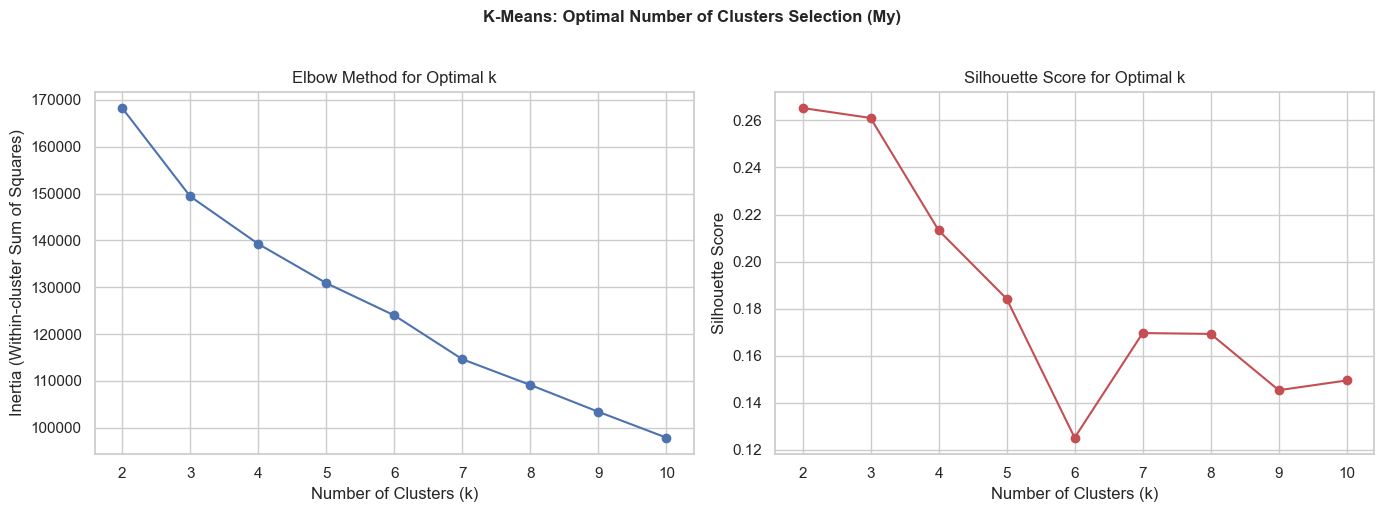

✓ Optimal number of clusters: 2
  Silhouette scores by k: {2: 0.2652, 3: 0.261, 4: 0.2133, 5: 0.1842, 6: 0.1252, 7: 0.1696, 8: 0.1693, 9: 0.1454, 10: 0.1495}
  Using my_df_clean with 17 features (same as original file)


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# Prepare data for clustering (exclude target variable)
# Using my_df_clean (My's preprocessed data) instead of df_clean
my_X_cluster = my_df_clean.drop(columns=['Revenue']).copy()

# Apply preprocessing using my_preprocessor (same as original file)
my_X_cluster_scaled = my_preprocessor.fit_transform(my_X_cluster)

# Find optimal K using Elbow method and Silhouette score
my_inertias = []
my_silhouette_scores = []
my_K_range = range(2, 11)

for k in my_K_range:
    my_kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    my_kmeans_tmp.fit(my_X_cluster_scaled)
    my_inertias.append(my_kmeans_tmp.inertia_)
    my_silhouette_scores.append(silhouette_score(my_X_cluster_scaled, my_kmeans_tmp.labels_))

# Visualize Elbow method and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(my_K_range, my_inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

axes[1].plot(my_K_range, my_silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True)

plt.suptitle('K-Means: Optimal Number of Clusters Selection (My)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Select optimal K based on highest silhouette score
my_optimal_k = my_K_range[np.argmax(my_silhouette_scores)]
print(f'✓ Optimal number of clusters: {my_optimal_k}')
print(f'  Silhouette scores by k: {dict(zip(my_K_range, [round(s, 4) for s in my_silhouette_scores]))}')
print(f'  Using my_df_clean with {my_X_cluster.shape[1]} features (same as original file)')

K-Means Silhouette Score: 0.2652


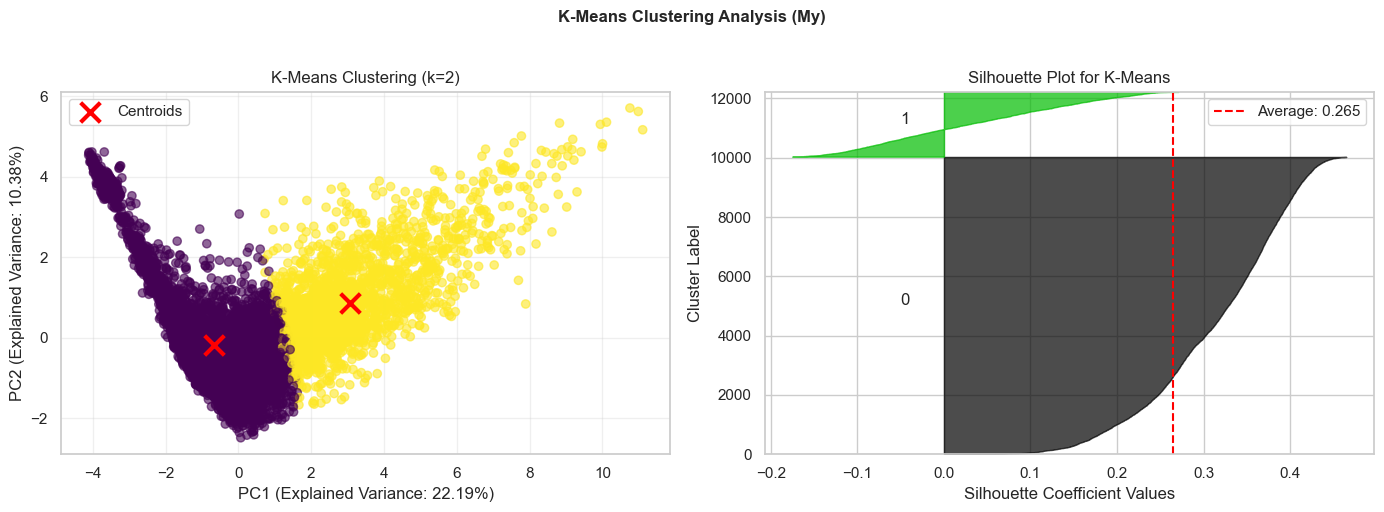


Cluster Sizes:
KMeans_Cluster
0    10019
1     2186
Name: count, dtype: int64

Revenue Distribution by Cluster:
Revenue              0       1
KMeans_Cluster                
0               0.8701  0.1299
1               0.7223  0.2777


In [51]:
# Fit K-Means with optimal number of clusters
my_kmeans = KMeans(n_clusters=my_optimal_k, random_state=42, n_init=10)
my_kmeans_labels = my_kmeans.fit_predict(my_X_cluster_scaled)

# Calculate silhouette score
my_silhouette_avg = silhouette_score(my_X_cluster_scaled, my_kmeans_labels)
print(f'K-Means Silhouette Score: {my_silhouette_avg:.4f}')

# PCA for 2D visualization
my_pca = PCA(n_components=2, random_state=42)
my_X_pca = my_pca.fit_transform(my_X_cluster_scaled)

# Visualize clusters and silhouette analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster scatter plot
scatter = axes[0].scatter(my_X_pca[:, 0], my_X_pca[:, 1], c=my_kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].scatter(my_pca.transform(my_kmeans.cluster_centers_)[:, 0],
                my_pca.transform(my_kmeans.cluster_centers_)[:, 1],
                c='red', marker='x', s=200, linewidths=3, label='Centroids')
axes[0].set_xlabel(f'PC1 (Explained Variance: {my_pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 (Explained Variance: {my_pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'K-Means Clustering (k={my_optimal_k})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
my_sample_silhouette_values = silhouette_samples(my_X_cluster_scaled, my_kmeans_labels)
y_lower = 10
for i in range(my_optimal_k):
    ith_cluster_silhouette_values = my_sample_silhouette_values[my_kmeans_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / my_optimal_k)
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
    axes[1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

axes[1].axvline(x=my_silhouette_avg, color="red", linestyle="--", label=f'Average: {my_silhouette_avg:.3f}')
axes[1].set_xlabel('Silhouette Coefficient Values')
axes[1].set_ylabel('Cluster Label')
axes[1].set_title('Silhouette Plot for K-Means')
axes[1].set_ylim([0, len(my_X_cluster_scaled) + (my_optimal_k + 1) * 10])
axes[1].legend()

plt.suptitle('K-Means Clustering Analysis (My)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analyze cluster characteristics
my_df_clustered = df_clean.copy()
my_df_clustered['KMeans_Cluster'] = my_kmeans_labels

print('\nCluster Sizes:')
print(my_df_clustered['KMeans_Cluster'].value_counts().sort_index())

print('\nRevenue Distribution by Cluster:')
print(pd.crosstab(my_df_clustered['KMeans_Cluster'], my_df_clustered['Revenue'], normalize='index').round(4))

## 4.2 Model 2: DBSCAN Clustering (My)

**Process:**
1. Use K-distance graph to find optimal eps parameter
2. Test multiple eps values and analyze cluster quality
3. Fit DBSCAN with optimal parameters
4. Compare with K-Means results

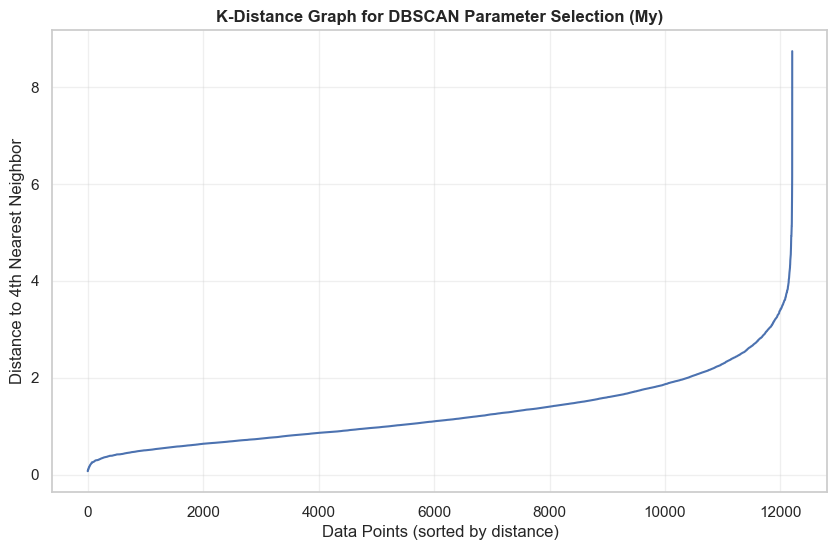

✓ Optimal eps: 2.90
  Number of clusters: 6
  Number of noise points: 280


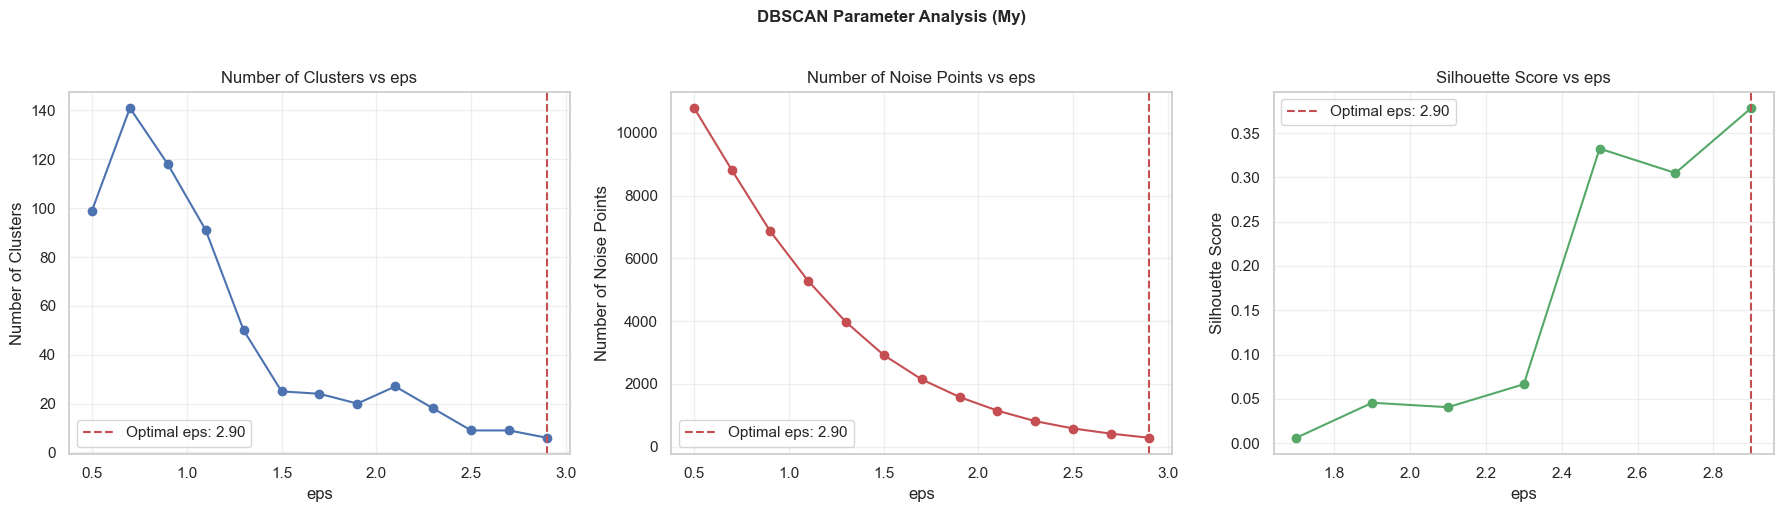

In [52]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Use the same preprocessed data
my_X_dbscan = my_X_cluster_scaled.copy()

# Find optimal eps using K-distance graph
my_k = 4  # min_samples parameter for DBSCAN
my_neighbors = NearestNeighbors(n_neighbors=my_k)
my_neighbors_fit = my_neighbors.fit(my_X_dbscan)
my_distances, my_indices = my_neighbors_fit.kneighbors(my_X_dbscan)

# Sort distances to kth nearest neighbor
my_distances = np.sort(my_distances, axis=0)
my_distances = my_distances[:, my_k-1]

# Plot K-distance graph (elbow indicates optimal eps)
plt.figure(figsize=(10, 6))
plt.plot(my_distances)
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'Distance to {my_k}th Nearest Neighbor')
plt.title('K-Distance Graph for DBSCAN Parameter Selection (My)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Test multiple eps values
my_eps_values = np.arange(0.5, 3.0, 0.2)
my_n_clusters_list = []
my_n_noise_list = []
my_silhouette_scores_dbscan = []

for eps in my_eps_values:
    my_dbscan_tmp = DBSCAN(eps=eps, min_samples=my_k)
    my_labels_tmp = my_dbscan_tmp.fit_predict(my_X_dbscan)
    
    # Count clusters (excluding noise label -1)
    n_clusters = len(set(my_labels_tmp)) - (1 if -1 in my_labels_tmp else 0)
    n_noise = list(my_labels_tmp).count(-1)
    my_n_clusters_list.append(n_clusters)
    my_n_noise_list.append(n_noise)
    
    # Calculate silhouette score (only if valid clustering exists)
    if n_clusters > 1 and n_noise < len(my_labels_tmp) * 0.5:
        mask = my_labels_tmp != -1
        if np.sum(mask) > 1:
            try:
                sil_score = silhouette_score(my_X_dbscan[mask], my_labels_tmp[mask])
                my_silhouette_scores_dbscan.append(sil_score)
            except:
                my_silhouette_scores_dbscan.append(-1)
        else:
            my_silhouette_scores_dbscan.append(-1)
    else:
        my_silhouette_scores_dbscan.append(-1)

# Find optimal eps based on silhouette score
my_valid_indices = [i for i, (nc, nn) in enumerate(zip(my_n_clusters_list, my_n_noise_list)) 
                   if 2 <= nc <= 8 and nn < len(my_X_dbscan) * 0.3 and my_silhouette_scores_dbscan[i] > 0]

if my_valid_indices:
    my_best_idx = my_valid_indices[np.argmax([my_silhouette_scores_dbscan[i] for i in my_valid_indices])]
    my_optimal_eps = my_eps_values[my_best_idx]
else:
    # Fallback: find reasonable number of clusters
    my_best_idx = None
    for i, (nc, nn) in enumerate(zip(my_n_clusters_list, my_n_noise_list)):
        if 3 <= nc <= 5 and nn < len(my_X_dbscan) * 0.2:
            my_best_idx = i
            break
    if my_best_idx is None:
        my_optimal_eps = 1.5
    else:
        my_optimal_eps = my_eps_values[my_best_idx]

print(f'✓ Optimal eps: {my_optimal_eps:.2f}')

if my_best_idx is not None:
    my_optimal_idx = my_best_idx
else:
    my_optimal_idx = np.argmin(np.abs(my_eps_values - my_optimal_eps))

print(f'  Number of clusters: {my_n_clusters_list[my_optimal_idx]}')
print(f'  Number of noise points: {my_n_noise_list[my_optimal_idx]}')

# Visualize eps parameter analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(my_eps_values, my_n_clusters_list, 'bo-')
axes[0].axvline(x=my_optimal_eps, color='r', linestyle='--', label=f'Optimal eps: {my_optimal_eps:.2f}')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Number of Clusters vs eps')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(my_eps_values, my_n_noise_list, 'ro-')
axes[1].axvline(x=my_optimal_eps, color='r', linestyle='--', label=f'Optimal eps: {my_optimal_eps:.2f}')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Number of Noise Points')
axes[1].set_title('Number of Noise Points vs eps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

my_valid_sil = [s if s > 0 else np.nan for s in my_silhouette_scores_dbscan]
axes[2].plot(my_eps_values, my_valid_sil, 'go-')
axes[2].axvline(x=my_optimal_eps, color='r', linestyle='--', label=f'Optimal eps: {my_optimal_eps:.2f}')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette Score vs eps')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('DBSCAN Parameter Analysis (My)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

DBSCAN Results:
  Number of clusters: 6
  Noise points: 280 (2.29%)
  Silhouette Score (excluding noise): 0.3783


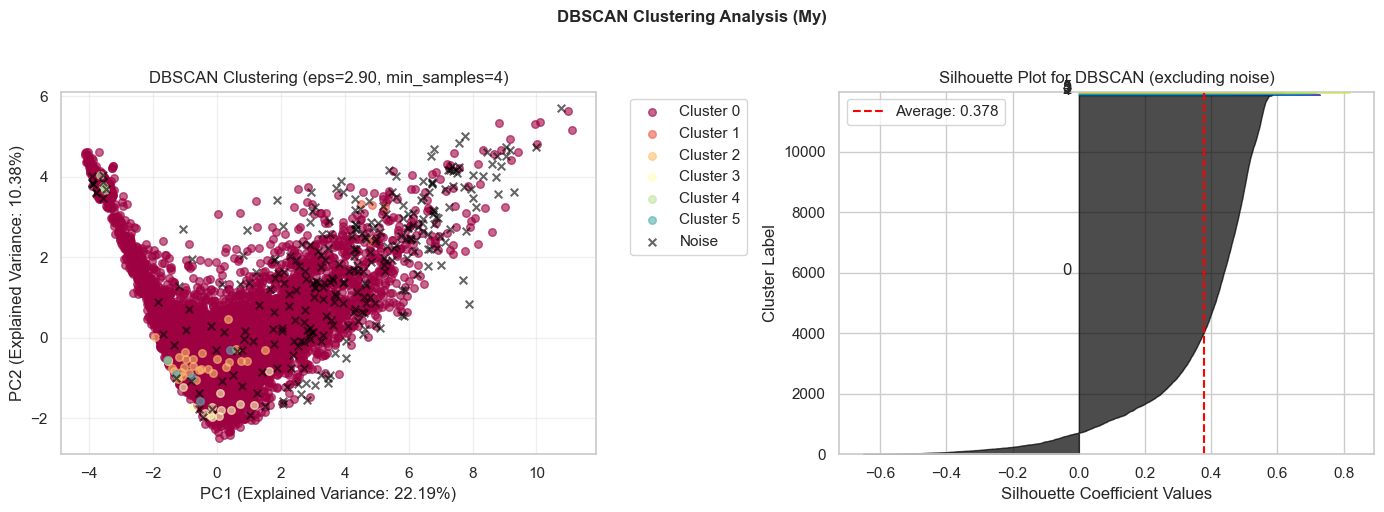


DBSCAN Cluster Sizes:
DBSCAN_Cluster
-1      280
 0    11867
 1        4
 2       32
 3       13
 4        4
 5        5
Name: count, dtype: int64

Revenue Distribution by Cluster (excluding noise):
Revenue              0       1
DBSCAN_Cluster                
0               0.8490  0.1510
1               1.0000  0.0000
2               0.9375  0.0625
3               0.0769  0.9231
4               1.0000  0.0000
5               0.6000  0.4000


In [53]:
# Fit DBSCAN with optimal parameters
my_dbscan = DBSCAN(eps=my_optimal_eps, min_samples=my_k)
my_dbscan_labels = my_dbscan.fit_predict(my_X_dbscan)

# Calculate clustering metrics
my_n_clusters_dbscan = len(set(my_dbscan_labels)) - (1 if -1 in my_dbscan_labels else 0)
my_n_noise_dbscan = list(my_dbscan_labels).count(-1)

print(f'DBSCAN Results:')
print(f'  Number of clusters: {my_n_clusters_dbscan}')
print(f'  Noise points: {my_n_noise_dbscan} ({my_n_noise_dbscan/len(my_dbscan_labels)*100:.2f}%)')

# Calculate silhouette score (excluding noise points)
my_mask_dbscan = my_dbscan_labels != -1
if my_n_clusters_dbscan > 1 and np.sum(my_mask_dbscan) > 1:
    my_silhouette_avg_dbscan = silhouette_score(my_X_dbscan[my_mask_dbscan], my_dbscan_labels[my_mask_dbscan])
    print(f'  Silhouette Score (excluding noise): {my_silhouette_avg_dbscan:.4f}')
else:
    my_silhouette_avg_dbscan = -1
    print('  Cannot calculate silhouette score (too few clusters or too many noise points)')

# Transform data for visualization using existing PCA
my_X_pca_dbscan = my_pca.transform(my_X_dbscan)

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster scatter plot
my_unique_labels = set(my_dbscan_labels)
my_colors = plt.cm.Spectral(np.linspace(0, 1, len(my_unique_labels)))

for label, color in zip(my_unique_labels, my_colors):
    if label == -1:
        color = 'black'
        marker = 'x'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'
    
    class_member_mask = (my_dbscan_labels == label)
    xy = my_X_pca_dbscan[class_member_mask]
    axes[0].scatter(xy[:, 0], xy[:, 1], c=[color], marker=marker, 
                   alpha=0.6, s=30, label=label_name)

axes[0].set_xlabel(f'PC1 (Explained Variance: {my_pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 (Explained Variance: {my_pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'DBSCAN Clustering (eps={my_optimal_eps:.2f}, min_samples={my_k})')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Silhouette plot (if valid)
if my_n_clusters_dbscan > 1 and np.sum(my_mask_dbscan) > 1:
    my_sample_silhouette_values_dbscan = silhouette_samples(my_X_dbscan[my_mask_dbscan], my_dbscan_labels[my_mask_dbscan])
    y_lower = 10
    
    for i in range(my_n_clusters_dbscan):
        ith_cluster_silhouette_values = my_sample_silhouette_values_dbscan[my_dbscan_labels[my_mask_dbscan] == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / my_n_clusters_dbscan)
        axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                             facecolor=color, edgecolor=color, alpha=0.7)
        axes[1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    axes[1].axvline(x=my_silhouette_avg_dbscan, color="red", linestyle="--", 
                   label=f'Average: {my_silhouette_avg_dbscan:.3f}')
    axes[1].set_xlabel('Silhouette Coefficient Values')
    axes[1].set_ylabel('Cluster Label')
    axes[1].set_title('Silhouette Plot for DBSCAN (excluding noise)')
    axes[1].set_ylim([0, np.sum(my_mask_dbscan) + (my_n_clusters_dbscan + 1) * 10])
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Cannot create silhouette plot\n(too few clusters or too many noise points)', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Silhouette Plot for DBSCAN')

plt.suptitle('DBSCAN Clustering Analysis (My)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analyze cluster characteristics
my_df_clustered['DBSCAN_Cluster'] = my_dbscan_labels

print('\nDBSCAN Cluster Sizes:')
my_cluster_counts = my_df_clustered['DBSCAN_Cluster'].value_counts().sort_index()
print(my_cluster_counts)

if my_n_clusters_dbscan > 0:
    print('\nRevenue Distribution by Cluster (excluding noise):')
    my_df_clustered_no_noise = my_df_clustered[my_df_clustered['DBSCAN_Cluster'] != -1]
    if len(my_df_clustered_no_noise) > 0:
        print(pd.crosstab(my_df_clustered_no_noise['DBSCAN_Cluster'], 
                         my_df_clustered_no_noise['Revenue'], normalize='index').round(4))

## 4.3 Clustering Methods Comparison (My)

Compare K-Means and DBSCAN results side by side.

CLUSTERING MODELS COMPARISON (My)

1. K-Means Clustering:
   • Number of clusters: 2
   • Silhouette Score: 0.2652
   • Inertia: 168271.36
   • All points assigned to clusters: Yes

2. DBSCAN Clustering:
   • Number of clusters: 6
   • Noise points: 280 (2.29%)
   • Silhouette Score (excluding noise): 0.3783
   • eps parameter: 2.90
   • min_samples parameter: 4

3. Key Differences:
   • K-Means: Assumes spherical clusters, requires pre-specifying k
   • DBSCAN: Can find clusters of arbitrary shape, identifies noise points
   • K-Means: All points assigned to clusters
   • DBSCAN: Can leave some points as noise (outliers)


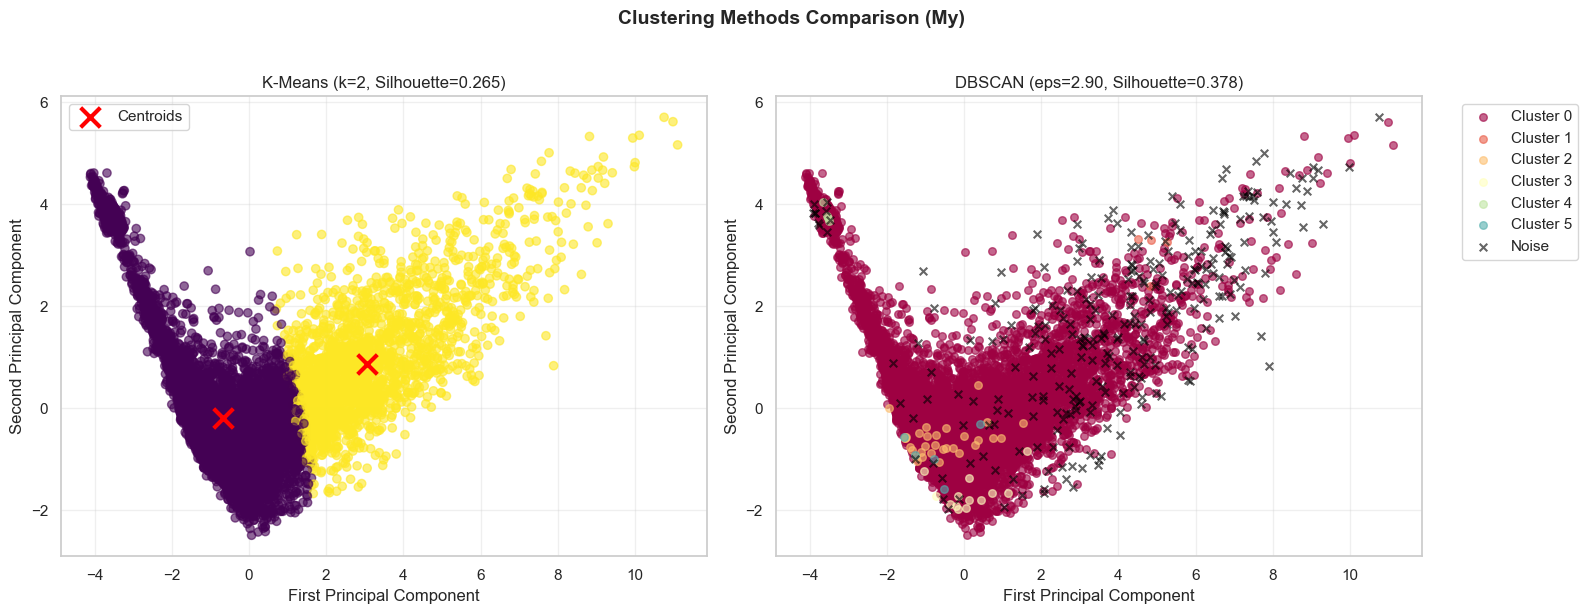

In [54]:
# Compare K-Means and DBSCAN clustering methods
print("=" * 60)
print("CLUSTERING MODELS COMPARISON (My)")
print("=" * 60)

print("\n1. K-Means Clustering:")
print(f"   • Number of clusters: {my_optimal_k}")
print(f"   • Silhouette Score: {my_silhouette_avg:.4f}")
print(f"   • Inertia: {my_kmeans.inertia_:.2f}")
print(f"   • All points assigned to clusters: Yes")

print("\n2. DBSCAN Clustering:")
print(f"   • Number of clusters: {my_n_clusters_dbscan}")
print(f"   • Noise points: {my_n_noise_dbscan} ({my_n_noise_dbscan/len(my_dbscan_labels)*100:.2f}%)")
if my_silhouette_avg_dbscan > 0:
    print(f"   • Silhouette Score (excluding noise): {my_silhouette_avg_dbscan:.4f}")
print(f"   • eps parameter: {my_optimal_eps:.2f}")
print(f"   • min_samples parameter: {my_k}")

print("\n3. Key Differences:")
print("   • K-Means: Assumes spherical clusters, requires pre-specifying k")
print("   • DBSCAN: Can find clusters of arbitrary shape, identifies noise points")
print("   • K-Means: All points assigned to clusters")
print("   • DBSCAN: Can leave some points as noise (outliers)")

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means visualization
scatter1 = axes[0].scatter(my_X_pca[:, 0], my_X_pca[:, 1], c=my_kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].scatter(my_pca.transform(my_kmeans.cluster_centers_)[:, 0],
                my_pca.transform(my_kmeans.cluster_centers_)[:, 1],
                c='red', marker='x', s=200, linewidths=3, label='Centroids')
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title(f'K-Means (k={my_optimal_k}, Silhouette={my_silhouette_avg:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DBSCAN visualization
my_unique_labels_dbscan = set(my_dbscan_labels)
my_colors_dbscan = plt.cm.Spectral(np.linspace(0, 1, len(my_unique_labels_dbscan)))

for label, color in zip(my_unique_labels_dbscan, my_colors_dbscan):
    if label == -1:
        color = 'black'
        marker = 'x'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'
    
    class_member_mask = (my_dbscan_labels == label)
    xy = my_X_pca_dbscan[class_member_mask]
    axes[1].scatter(xy[:, 0], xy[:, 1], c=[color], marker=marker, 
                   alpha=0.6, s=30, label=label_name)

axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
if my_silhouette_avg_dbscan > 0:
    axes[1].set_title(f'DBSCAN (eps={my_optimal_eps:.2f}, Silhouette={my_silhouette_avg_dbscan:.3f})')
else:
    axes[1].set_title(f'DBSCAN (eps={my_optimal_eps:.2f})')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Clustering Methods Comparison (My)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()